# Project "Prediction of the car’s value"


**Цель проекта**

Создать автоматизированную ML‑систему оценки стоимости подержанных автомобилей для стартапа AutoValue AI, которая заменит ручную работу экспертов, обеспечит мгновенный расчёт цены (в пределах 1 секунды) и сбалансирует бизнес‑риски: минимизирует опасные переплаты при выкупе и упущенную выгоду из‑за заниженных предложений.

**Задачи**

- Тип задачи - обучение с учителем, задача регрессии

- Построить регрессионную модель, способную быстро (≤1 с на прогноз) и стабильно предсказывать цену автомобиля по структурированным признакам. Обеспечить воспроизводимость и отсутствие субъективности за счёт фиксированного пайплайна предобработки и модели.

- Включить признак region как категориальный и корректно закодировать его (One‑Hot / Target Encoding), чтобы модель научилась различать региональные ценовые паттерны. При необходимости обучить отдельные модели по регионам или добавить взаимодействия признаков с регионом.

- Выделить и усилить информативные признаки: использовать brand, make_year, mileage_kmpl, owner_count и их комбинации (например, средний годовой пробег, отношение владельцев к возрасту авто). Добавить признаки‑отношения и взаимодействия, чтобы модель улавливала эти нюансы.

- Оптимизировать модель под снижение доли опасных переплат (Overpricing Rate). Рассмотреть смещение прогноза в сторону осторожности (например, квантильную регрессию или смещение предсказаний вниз) при сохранении общей точности.

- Контролировать упущенную выгоду (Underpricing Loss) как одну из ключевых метрик. Настроить баланс между точностью и смещением прогноза, чтобы не терять долю рынка.

- Провести сравнительный бенчмарк трёх градиентных бустингов на одних и тех же данных и пайплайнах. Для каждой библиотеки подобрать гиперпараметры (GridSearch / Optuna), зафиксировать метрики качества и скорость инференса, выбрать победителя по бизнес‑метрикам и стабильности.

- Реализовать интерпретируемость: вывести важность признаков (feature importance), SHAP‑значения для типичных кейсов, примеры влияния отдельных факторов на прогноз цены. Подготовить отчёт с примерами: «почему цена выросла/упала на X рублей».

- Использовать фиксированный тестовый набор (ds_s16_test_data.csv) только для финальной оценки. Все этапы обучения, валидации и подбора гиперпараметров проводить на тренировочной выборке (ds_s16_train_data.csv) с кросс‑валидацией.

**Признаки**

`brand`	- Марка автомобиля	Фундамент цены: престиж и надёжность бренда.

`make_year`	- Год выпуска. Главный счётчик амортизации: чем старше автомобиль, тем дешевле.

`mileage_kmpl` - KMPL (kilometres per litre) — это единица измерения топливной эффективности транспортного средства, которая показывает, сколько километров автомобиль может проехать на одном литре топлива.

`engine_cc` - Объём двигателя (в кубических см). Влияет на мощность, налоги и интерес покупателей.

`fuel_type`	- Тип топлива. Экономичность против мощности. Важный фактор ликвидности.

`transmission`	- Тип коробки передач. «Автомат» или «механика» — ключевой фактор комфорта.

`owner_count` - Количество владельцев по ПТС. Юридическая чистота и аккуратность эксплуатации.

`color`	- Цвет автомобиля. Психологический фактор: популярные цвета продаются быстрее.

`service_history` - Наличие сервисной книжки. Подтверждает, что за машиной ухаживали вовремя.

`accidents_reported` - Количество зафиксированных ДТП. Сильно бьёт по цене и безопасности будущей сделки.

`insurance_valid` - Действительна ли страховка. Снижает первичные расходы покупателя после сделки.

`region` - Макрорегион РФ, в котором продаётся автомобиль (Москва, Сибирь, Юг). Позволяет модели учитывать региональную специфику цен.

`price_rub` - Целевой признак: рыночная стоимость автомобиля в рублях. Реальная сумма сделки, которую нужно предсказать.





## Исследовательский анализ данных



### Загрузка бибилотек и данных

In [1]:
!pip install phik -q
!pip install optuna -q
!pip install --upgrade xgboost -q

In [2]:
!pip install shap -q

In [3]:
# Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import time
import optuna
import shap
from phik import phik_matrix
from datetime import date
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, make_scorer

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor, early_stopping, log_evaluation
from catboost import CatBoostRegressor, Pool

import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="lightgbm")

RANDOM_STATE = 42

In [4]:
import xgboost
print(xgboost.__version__)

2.1.4


In [5]:
train_df = pd.read_csv('/datasets/ds_s16_train_data.csv')
test_df = pd.read_csv('/datasets/ds_s16_test_data.csv')

In [6]:
display(train_df.head())
display(train_df.info())

,make_year,mileage_kmpl,engine_cc,fuel_type,owner_count,brand,transmission,color,service_history,accidents_reported,insurance_valid,price_rub,region
0,2002,9.70,1800,Diesel,2,Hyundai,Manual,Silver,Partial,0,No,242073,Урал
1,2004,16.10,1500,Diesel,3,Hyundai,Manual,Black,Unknown,0,No,426029,Москва
2,2005,10.51,5000,Diesel,2,Ford,Manual,Gray,Full,0,No,727050,Юг
3,2019,14.27,2000,Petrol,5,Hyundai,Manual,White,Full,1,Yes,753168,Дальний Восток
4,2015,21.72,1000,Petrol,1,Toyota,Automatic,Black,Full,0,Yes,733390,Сибирь


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   make_year           8000 non-null   int64  
 1   mileage_kmpl        8000 non-null   float64
 2   engine_cc           8000 non-null   int64  
 3   fuel_type           8000 non-null   object 
 4   owner_count         8000 non-null   int64  
 5   brand               8000 non-null   object 
 6   transmission        8000 non-null   object 
 7   color               8000 non-null   object 
 8   service_history     8000 non-null   object 
 9   accidents_reported  8000 non-null   int64  
 10  insurance_valid     8000 non-null   object 
 11  price_rub           8000 non-null   int64  
 12  region              8000 non-null   object 
dtypes: float64(1), int64(5), object(7)
memory usage: 812.6+ KB


None

In [7]:
display(test_df.head())
display(test_df.info())

,make_year,mileage_kmpl,engine_cc,fuel_type,owner_count,brand,transmission,color,service_history,accidents_reported,insurance_valid,price_rub,region
0,2015,12.09,5000,Diesel,1,Nissan,Automatic,White,Full,2,No,1213351,Москва
1,2016,14.03,800,Petrol,4,Chevrolet,Manual,White,Partial,0,Yes,586881,Дальний Восток
2,2005,20.40,2000,Petrol,1,Kia,Manual,Blue,Full,2,Yes,650752,Сибирь
3,1996,25.09,800,Diesel,3,Volkswagen,Manual,Silver,Full,0,Yes,320452,Урал
4,1995,19.25,5000,Diesel,5,Hyundai,Automatic,Black,Partial,0,No,694911,СПб


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   make_year           2000 non-null   int64  
 1   mileage_kmpl        2000 non-null   float64
 2   engine_cc           2000 non-null   int64  
 3   fuel_type           2000 non-null   object 
 4   owner_count         2000 non-null   int64  
 5   brand               2000 non-null   object 
 6   transmission        2000 non-null   object 
 7   color               2000 non-null   object 
 8   service_history     2000 non-null   object 
 9   accidents_reported  2000 non-null   int64  
 10  insurance_valid     2000 non-null   object 
 11  price_rub           2000 non-null   int64  
 12  region              2000 non-null   object 
dtypes: float64(1), int64(5), object(7)
memory usage: 203.2+ KB


None

**Промежуточный вывод по предоставленным данным**

Данные для обучения представлены в виде датасета размером 8000х13. Данные соответствуют описанию, отсутствуют пропущенные значения. В тестовом датасете пропусков также нет, размер предоставленных данных 2000 строк.

### Анализ на дубликаты

In [8]:
# Полные дубликаты
full_dup = train_df.duplicated()
n_full_dup = full_dup.sum()
print(f"Полных дубликатов: {n_full_dup}")

if n_full_dup > 0:
    print("Примеры полных дубликатов:")
    print(df[full_dup].head())

Полных дубликатов: 0


In [9]:
key_cols = ["brand", "mileage_kmpl", "engine_cc",  'price_rub']

dup_by_key = test_df.duplicated(subset=key_cols, keep=False) 
n_dup_by_key = dup_by_key.sum()
print(f"Строк, имеющих дубль по ключевой комбинации: {n_dup_by_key}")


Строк, имеющих дубль по ключевой комбинации: 0


**Промежуточный вывод по анализу на дубликаты**

В данных отсутствуют полные дубликаты. При анализе данных по ключевым полям дубликатов также найдено не было

### Анализ целевой переменной 

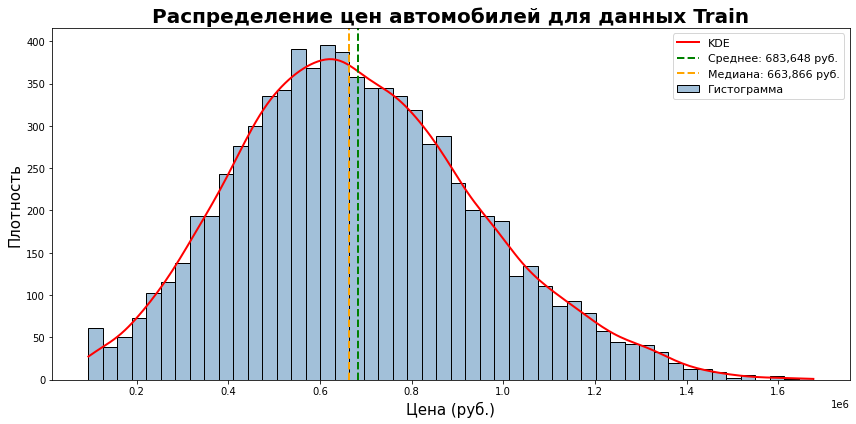

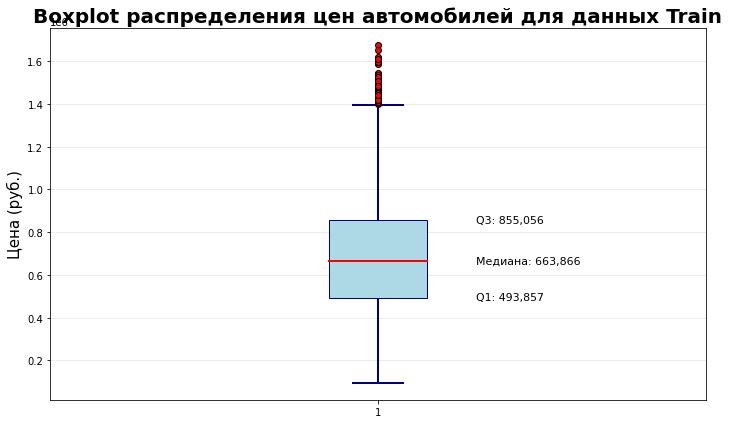

=== Анализ целевой переменной: Train ===
Count: 8000
Min: 95,000
Max: 1,676,525
Mean: 683,648
Median: 663,866
Std: 264,923
Skewness: 0.34
Kurtosis: -0.10
Q1: 493,857, Q3: 855,056, IQR: 361,199
Границы выбросов (1.5*IQR): [-47,942; 1,396,854]
Количество выбросов: 45 (0.56%)
----------------------------------------


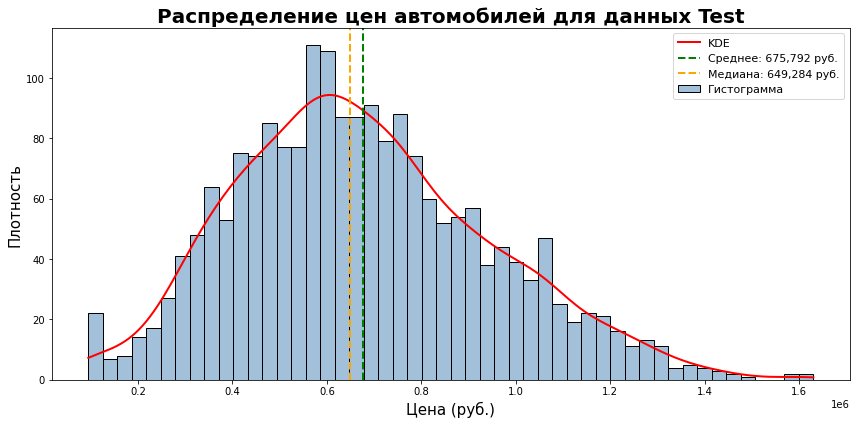

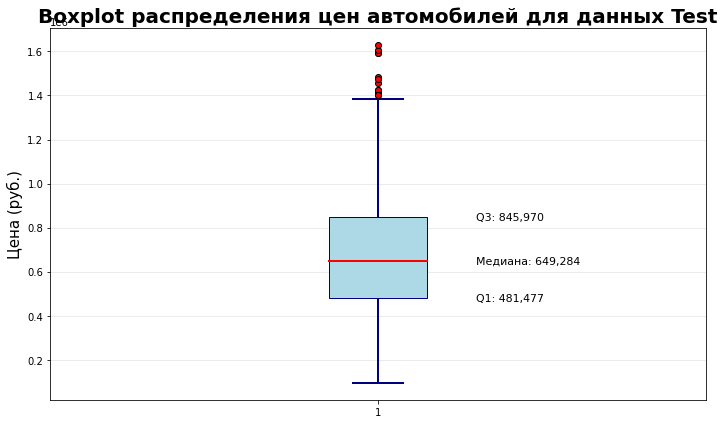

=== Анализ целевой переменной: Test ===
Count: 2000
Min: 95,000
Max: 1,629,774
Mean: 675,792
Median: 649,284
Std: 268,020
Skewness: 0.41
Kurtosis: -0.07
Q1: 481,477, Q3: 845,970, IQR: 364,492
Границы выбросов (1.5*IQR): [-65,262; 1,392,708]
Количество выбросов: 13 (0.65%)
----------------------------------------


In [10]:
def print_histplot(df, column, df_name):
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.histplot(df[column], bins=50, kde=True,
                 color='steelblue', edgecolor='black', label='Гистограмма')
    for line in ax.lines:
        line.set_color('red')
        line.set_linewidth(2)
        line.set_label('KDE')
    ax.axvline(df[column].mean(), color='green', linestyle='--', linewidth=2,
               label=f'Среднее: {df[column].mean():,.0f} руб.')
    ax.axvline(df[column].median(), color='orange', linestyle='--', linewidth=2,
               label=f'Медиана: {df[column].median():,.0f} руб.')
    ax.set_xlabel('Цена (руб.)', fontsize=15)
    ax.set_ylabel('Плотность', fontsize=15)
    ax.set_title(f'Распределение цен автомобилей для данных {df_name}', fontsize=20, fontweight='bold')
    ax.legend(fontsize=11)
    plt.tight_layout()
    plt.show()

def print_boxplot(df, column, df_name):
    fig, ax = plt.subplots(figsize=(10, 6))
    boxplot = ax.boxplot(df[column], vert=True, patch_artist=True,
                         boxprops=dict(facecolor='lightblue', color='navy'),
                         medianprops=dict(color='red', linewidth=2),
                         whiskerprops=dict(color='navy', linewidth=2),
                         capprops=dict(color='navy', linewidth=2),
                         flierprops=dict(markerfacecolor='red', marker='o', markersize=6))
    ax.set_ylabel('Цена (руб.)', fontsize=15)
    ax.set_title(f'Boxplot распределения цен автомобилей для данных {df_name}', fontsize=20, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    median = df[column].median()
    IQR = Q3 - Q1

    ax.text(1.15, median, f'Медиана: {median:,.0f}', va='center', fontsize=11)
    ax.text(1.15, Q1, f'Q1: {Q1:,.0f}', va='center', fontsize=11)
    ax.text(1.15, Q3, f'Q3: {Q3:,.0f}', va='center', fontsize=11)

    plt.tight_layout()
    plt.show()
    return Q1, Q3, median, IQR

# Статистика по целевой переменной
def analyze_target_distribution(df, name):
    y = df['price_rub']
    Q1, Q3, median, IQR = y.quantile(0.25), y.quantile(0.75), y.median(), y.quantile(0.75) - y.quantile(0.25)
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = y[(y < lower_bound) | (y > upper_bound)]

    print(f"=== Анализ целевой переменной: {name} ===")
    print(f"Count: {len(y)}")
    print(f"Min: {y.min():,.0f}")
    print(f"Max: {y.max():,.0f}")
    print(f"Mean: {y.mean():,.0f}")
    print(f"Median: {y.median():,.0f}")
    print(f"Std: {y.std():,.0f}")
    print(f"Skewness: {y.skew():.2f}")
    print(f"Kurtosis: {y.kurt():.2f}")
    print(f"Q1: {Q1:,.0f}, Q3: {Q3:,.0f}, IQR: {IQR:,.0f}")
    print(f"Границы выбросов (1.5*IQR): [{lower_bound:,.0f}; {upper_bound:,.0f}]")
    print(f"Количество выбросов: {len(outliers)} ({len(outliers)/len(y)*100:.2f}%)")
    print("-" * 40)
    return {'Q1': Q1, 'Q3': Q3, 'median': median, 'IQR': IQR, 'outliers_count': len(outliers), 'outliers_pct': len(outliers)/len(y)}

# Вызов графиков и статистики
print_histplot(train_df, 'price_rub', 'Train')
print_boxplot(train_df, 'price_rub', 'Train')
stats_train = analyze_target_distribution(train_df, "Train")

print_histplot(test_df, 'price_rub', 'Test')
print_boxplot(test_df, 'price_rub', 'Test')
stats_test = analyze_target_distribution(test_df, "Test")

Исследование показало, что данные целевой переменной имеют нормальное распределение, нет явных выбросов и аномалий

count    8000.000000
mean     2009.221250
std         8.388703
min      1995.000000
25%      2002.000000
50%      2009.000000
75%      2017.000000
max      2023.000000
Name: make_year, dtype: float64
Уникальные значения: [1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]


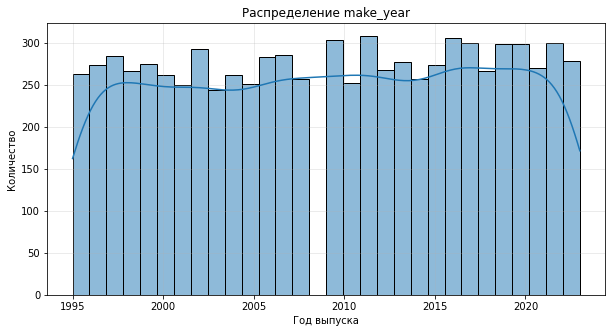

In [11]:
# Базовые статистики
print(train_df['make_year'].describe())
print("Уникальные значения:", sorted(train_df['make_year'].unique()))

# Распределение
plt.figure(figsize=(10,5))
sns.histplot(train_df['make_year'], bins=30, kde=True)
plt.title('Распределение make_year')
plt.xlabel('Год выпуска')
plt.ylabel('Количество')
plt.grid(True, alpha=0.3)
plt.show()


count    2000.000000
mean       18.018395
std         5.065829
min         5.000000
25%        14.570000
50%        18.005000
75%        21.382500
max        34.380000
Name: mileage_kmpl, dtype: float64


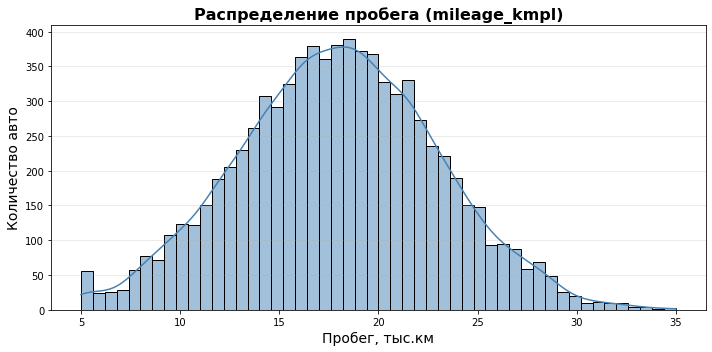

In [12]:
# Статистика пробега
print(test_df['mileage_kmpl'].describe())

# Гистограмма пробега (mileage_kmpl)
plt.figure(figsize=(10, 5))
sns.histplot(train_df['mileage_kmpl'], bins=50, kde=True, color='steelblue', edgecolor='black')
plt.title('Распределение пробега (mileage_kmpl)', fontsize=16, fontweight='bold')
plt.xlabel('Пробег, тыс.км', fontsize=14)
plt.ylabel('Количество авто', fontsize=14)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()



count    8000.000000
mean     2289.687500
std      1289.812139
min       800.000000
25%      1200.000000
50%      2000.000000
75%      3000.000000
max      5000.000000
Name: engine_cc, dtype: float64


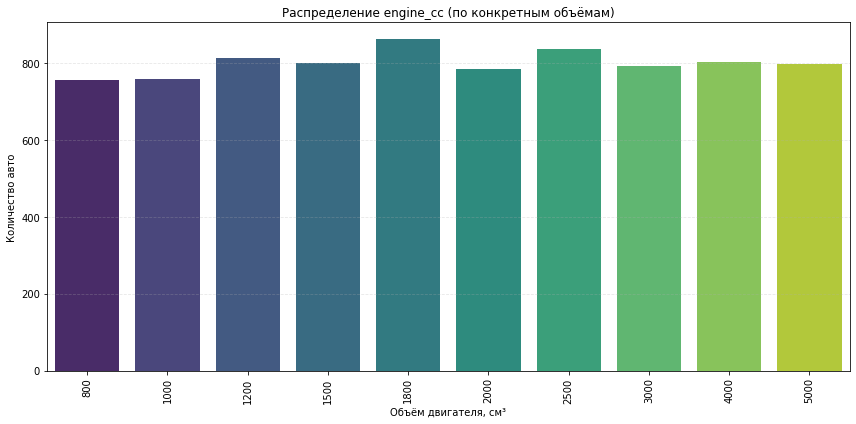

In [13]:
# Статистика по объёму двигателя
print(train_df['engine_cc'].describe())

# Столбчатая диаграмма 
plt.figure(figsize=(12, 6))
counts_cc = train_df['engine_cc'].value_counts().sort_index()
sns.barplot(x=counts_cc.index, y=counts_cc.values, palette="viridis")
plt.title('Распределение engine_cc (по конкретным объёмам)')
plt.xlabel('Объём двигателя, см³')
plt.ylabel('Количество авто')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


Petrol      3990
Diesel      3213
Electric     797
Name: fuel_type, dtype: int64
Уникальные значения: ['Diesel' 'Petrol' 'Electric']


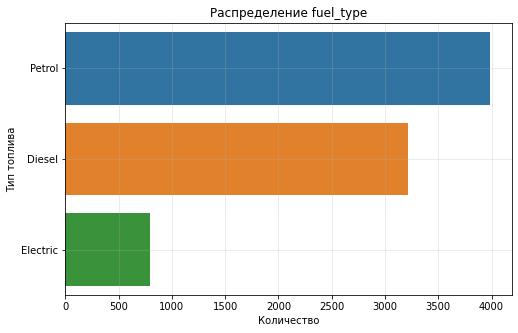

In [14]:
print(train_df['fuel_type'].value_counts())
print("Уникальные значения:", train_df['fuel_type'].unique())

plt.figure(figsize=(8,5))
sns.countplot(y=train_df['fuel_type'], order=train_df['fuel_type'].value_counts().index)
plt.title('Распределение fuel_type')
plt.xlabel('Количество')
plt.ylabel('Тип топлива')
plt.grid(True, alpha=0.3)
plt.show()

1    1594
2    1634
3    1576
4    1561
5    1635
Name: owner_count, dtype: int64


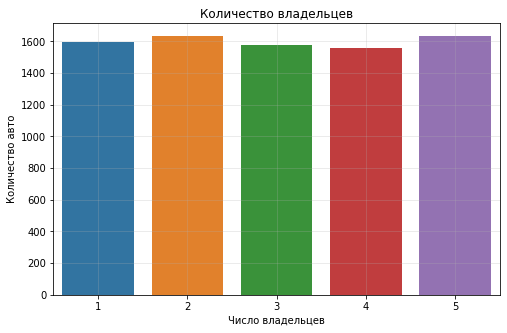

In [15]:
print(train_df['owner_count'].value_counts().sort_index())
plt.figure(figsize=(8,5))
sns.countplot(x=train_df['owner_count'], order=sorted(train_df['owner_count'].unique()))
plt.title('Количество владельцев')
plt.xlabel('Число владельцев')
plt.ylabel('Количество авто')
plt.grid(True, alpha=0.3)
plt.show()


Nissan        870
Volkswagen    831
BMW           827
Honda         804
Chevrolet     800
Toyota        792
Hyundai       785
Tesla         784
Kia           765
Ford          742
Name: brand, dtype: int64
Число уникальных брендов: 10


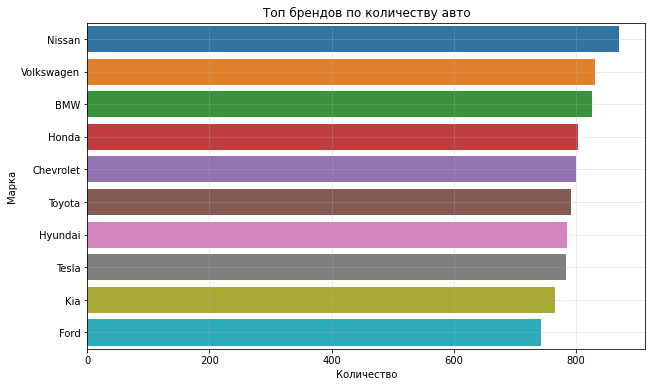

In [16]:
print(train_df['brand'].value_counts())
print("Число уникальных брендов:", train_df['brand'].nunique())

plt.figure(figsize=(10,6))
sns.countplot(y=train_df['brand'], order=train_df['brand'].value_counts().index)
plt.title('Топ брендов по количеству авто')
plt.xlabel('Количество')
plt.ylabel('Марка')
plt.grid(True, alpha=0.3)
plt.show()

Manual       4812
Automatic    3188
Name: transmission, dtype: int64


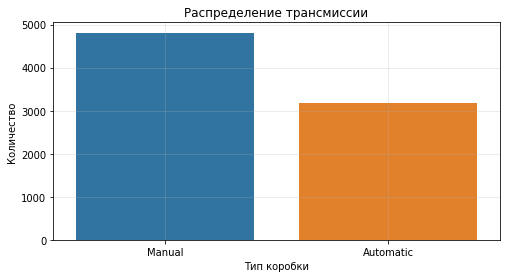

In [17]:
print(train_df['transmission'].value_counts())
plt.figure(figsize=(8,4))
sns.countplot(x=train_df['transmission'], order=train_df['transmission'].value_counts().index)
plt.title('Распределение трансмиссии')
plt.xlabel('Тип коробки')
plt.ylabel('Количество')
plt.grid(True, alpha=0.3)
plt.show()

White     1366
Black     1355
Red       1347
Gray      1340
Blue      1298
Silver    1294
Name: color, dtype: int64
Уникальных цветов: 6


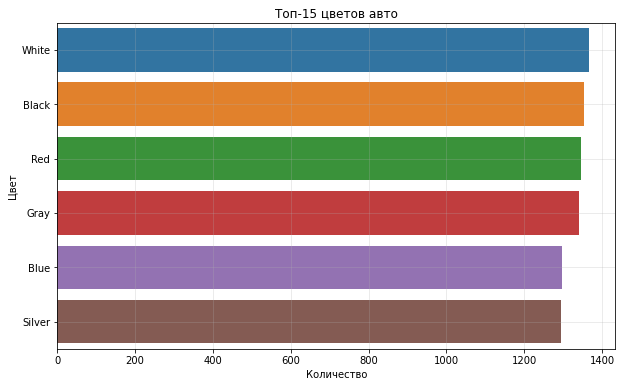

In [18]:
print(train_df['color'].value_counts())
print("Уникальных цветов:", train_df['color'].nunique())

plt.figure(figsize=(10,6))
sns.countplot(y=train_df['color'], order=train_df['color'].value_counts().head(15).index)
plt.title('Топ-15 цветов авто')
plt.xlabel('Количество')
plt.ylabel('Цвет')
plt.grid(True, alpha=0.3)
plt.show()

Full       3985
Partial    2362
Unknown    1653
Name: service_history, dtype: int64


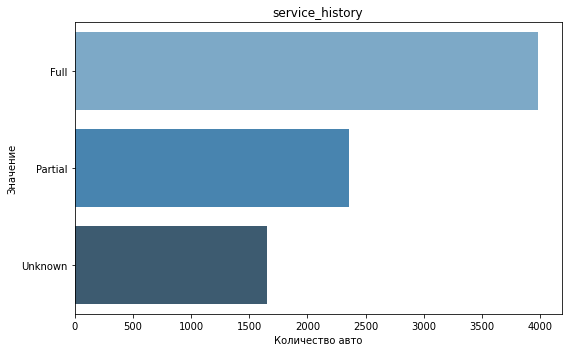

In [19]:
# Статистика по исходному признаку
print(train_df['service_history'].value_counts())

# Диаграмма по исходным значениям
plt.figure(figsize=(8, 5))
counts_raw = train_df['service_history'].value_counts()
sns.barplot(x=counts_raw.values, y=counts_raw.index, palette="Blues_d")
plt.title('service_history')
plt.xlabel('Количество авто')
plt.ylabel('Значение')
plt.tight_layout()
plt.show()

0    4898
1    2414
2     585
3      95
4       6
5       2
Name: accidents_reported, dtype: int64


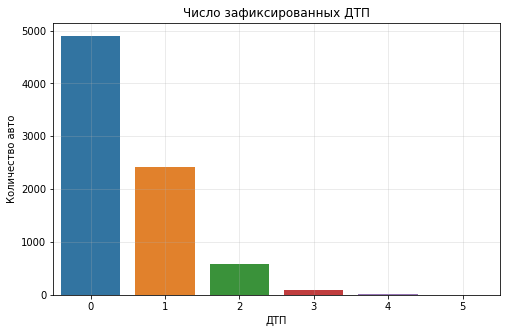

In [20]:
print(train_df['accidents_reported'].value_counts().sort_index())
plt.figure(figsize=(8,5))
sns.countplot(x=train_df['accidents_reported'], order=sorted(train_df['accidents_reported'].unique()))
plt.title('Число зафиксированных ДТП')
plt.xlabel('ДТП')
plt.ylabel('Количество авто')
plt.grid(True, alpha=0.3)
plt.show()


1    6356
0    1644
Name: insurance_valid, dtype: int64


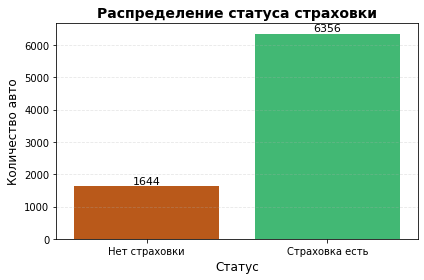

In [21]:
positives = ["yes", "да", "true", "1", "есть", "имеется"]
lower_positives = [x.lower() for x in positives]

# Приводим к строке, заменяем NaN на пустую строку, делаем lower, проверяем вхождение, конвертируем в int
train_df['insurance_valid'] = (
    train_df['insurance_valid']
    .astype(str)                 # всё в строку (NaN станет 'nan')
    .str.lower()                 # в нижний регистр
    .isin(lower_positives)       # проверка вхождения
    .astype(int)                 # 0/1
)

print(train_df['insurance_valid'].value_counts())

# Столбчатая диаграмма
plt.figure(figsize=(6, 4))
counts_bin = train_df['insurance_valid'].value_counts().sort_index()

sns.barplot(x=counts_bin.index, y=counts_bin.values, palette=["#d35400", "#2ecc71"])  # оранжевый (нет), зелёный (есть)

plt.xticks([0, 1], ['Нет страховки', 'Страховка есть'])
plt.title('Распределение статуса страховки', fontsize=14, fontweight='bold')
plt.xlabel('Статус', fontsize=12)
plt.ylabel('Количество авто', fontsize=12)

# Подписи значений на столбцах
for p in plt.gca().patches:
    height = p.get_height()
    plt.annotate(str(int(height)),
                 (p.get_x() + p.get_width() / 2, height),
                 ha='center', va='bottom', fontsize=11, color='black')

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

Юг                1408
Урал              1371
СПб               1346
Москва            1319
Дальний Восток    1295
Сибирь            1261
Name: region, dtype: int64


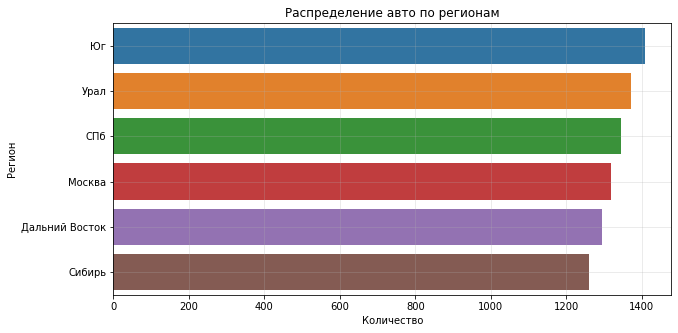

In [22]:
print(train_df['region'].value_counts())
plt.figure(figsize=(10,5))
sns.countplot(y=train_df['region'], order=train_df['region'].value_counts().index)
plt.title('Распределение авто по регионам')
plt.xlabel('Количество')
plt.ylabel('Регион')
plt.grid(True, alpha=0.3)
plt.show()


**Промежуточный вывод по исследованию признаков**

- Данные представлены в период с 1995 по 2023 года включительно, распределение равномерное, без резких завышений и падений в определенные пириоды
- Данные по пробегу демонстрируют нормальное распределение, с медианным значением в 18, что совпадает со средним значением
- По объму двигателя мы имеем машины от 800 до 5000 куб.см. явных лидеров нет. 
- По типу топлива видны вполне очевидные цифры. Бензин и дизель являются самыми популярными, электричек почти в 5 раз меньше, что характерно для Российского рынка. 
- У большинства авто есть страховка с сервискной историей и отсутствие(либо малое количество) ДТП
- Распределение количества авто по другим признакам равномерное

### Зависимость с целевой пременной 

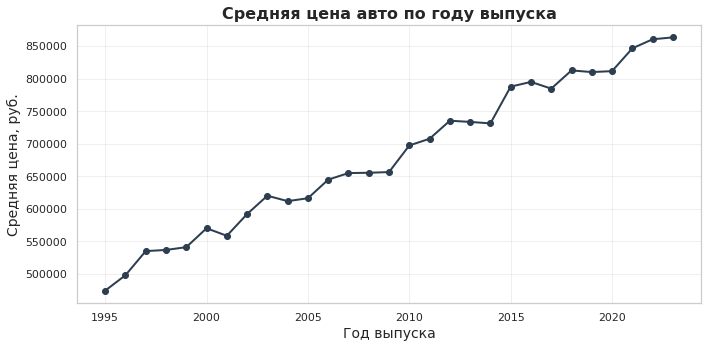

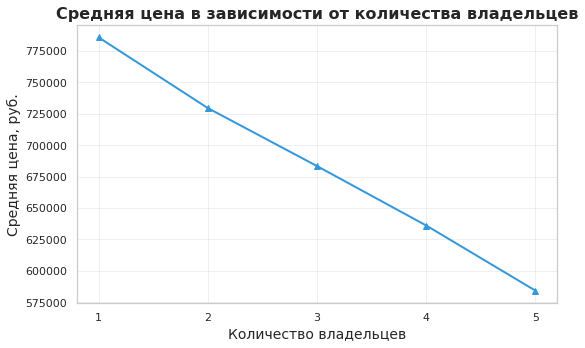

In [23]:
sns.set(style="whitegrid")

# --- 1. Средняя цена по году выпуска (make_year) ---
plt.figure(figsize=(10, 5))
year_price = train_df.groupby('make_year')['price_rub'].mean().sort_index()
plt.plot(year_price.index, year_price.values, marker='o', linewidth=2, markersize=6, color='#2c3e50')
plt.title('Средняя цена авто по году выпуска', fontsize=16, fontweight='bold')
plt.xlabel('Год выпуска', fontsize=14)
plt.ylabel('Средняя цена, руб.', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- 2. Средняя цена по количеству владельцев (owner_count) ---
plt.figure(figsize=(8, 5))
owner_price = train_df.groupby('owner_count')['price_rub'].mean().sort_index()
plt.plot(owner_price.index, owner_price.values, marker='^', linewidth=2, markersize=6, color='#3498db')
plt.title('Средняя цена в зависимости от количества владельцев', fontsize=16, fontweight='bold')
plt.xlabel('Количество владельцев', fontsize=14)
plt.ylabel('Средняя цена, руб.', fontsize=14)
plt.xticks(owner_price.index)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



По графикам можем видеть строгую линеную корреляцию: чем новее машина тем больше цена, чем больше владельцев тем цена меньше. 

### Анализ на соответствие тестовых данных тренировочным

In [24]:
display(test_df.head(5))
display(test_df.info())
display(test_df.shape)
display(test_df.columns)
display(test_df.describe())

,make_year,mileage_kmpl,engine_cc,fuel_type,owner_count,brand,transmission,color,service_history,accidents_reported,insurance_valid,price_rub,region
0,2015,12.09,5000,Diesel,1,Nissan,Automatic,White,Full,2,No,1213351,Москва
1,2016,14.03,800,Petrol,4,Chevrolet,Manual,White,Partial,0,Yes,586881,Дальний Восток
2,2005,20.40,2000,Petrol,1,Kia,Manual,Blue,Full,2,Yes,650752,Сибирь
3,1996,25.09,800,Diesel,3,Volkswagen,Manual,Silver,Full,0,Yes,320452,Урал
4,1995,19.25,5000,Diesel,5,Hyundai,Automatic,Black,Partial,0,No,694911,СПб


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   make_year           2000 non-null   int64  
 1   mileage_kmpl        2000 non-null   float64
 2   engine_cc           2000 non-null   int64  
 3   fuel_type           2000 non-null   object 
 4   owner_count         2000 non-null   int64  
 5   brand               2000 non-null   object 
 6   transmission        2000 non-null   object 
 7   color               2000 non-null   object 
 8   service_history     2000 non-null   object 
 9   accidents_reported  2000 non-null   int64  
 10  insurance_valid     2000 non-null   object 
 11  price_rub           2000 non-null   int64  
 12  region              2000 non-null   object 
dtypes: float64(1), int64(5), object(7)
memory usage: 203.2+ KB


None

(2000, 13)

Index(['make_year', 'mileage_kmpl', 'engine_cc', 'fuel_type', 'owner_count',
       'brand', 'transmission', 'color', 'service_history',
       'accidents_reported', 'insurance_valid', 'price_rub', 'region'],
      dtype='object')

,make_year,mileage_kmpl,engine_cc,owner_count,accidents_reported,price_rub
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2.000000e+03
mean,2009.149500,18.018395,2276.900000,3.01300,0.509500,6.757919e+05
std,8.316052,5.065829,1297.392772,1.41804,0.695091,2.680196e+05
min,1995.000000,5.000000,800.000000,1.00000,0.000000,9.500000e+04
25%,2002.000000,14.570000,1200.000000,2.00000,0.000000,4.814770e+05
50%,2009.000000,18.005000,1800.000000,3.00000,0.000000,6.492840e+05
75%,2016.000000,21.382500,3000.000000,4.00000,1.000000,8.459695e+05
max,2023.000000,34.380000,5000.000000,5.00000,4.000000,1.629774e+06


In [25]:
def check_train_test_compatibility(train_df, test_df, target_col='price_rub'):
    
    issues = []

    # 1. Проверка колонок (кроме целевой)
    train_cols = [c for c in train_df.columns if c != target_col]
    test_cols = [c for c in test_df.columns if c != target_col]

    if set(train_cols) != set(test_cols):
        issues.append(f"Разные наборы колонок: train={set(train_cols)}, test={set(test_cols)}")

    if train_cols != test_cols:
        issues.append("Порядок колонок отличается. Для пайплайна лучше привести к одному порядку.")
        # Приводим тест к порядку train (без target)
        test_df = test_df[train_cols + ([target_col] if target_col in test_df.columns else [])]

    # 2. Проверка типов данных по колонкам
    for col in train_cols:
        if col not in test_df.columns:
            issues.append(f"Колонка '{col}' есть в train, но отсутствует в test")
            continue
        train_dtype = train_df[col].dtype
        test_dtype = test_df[col].dtype
        if not np.issubdtype(train_dtype, np.number) and not np.issubdtype(test_dtype, np.number):
            # Для нечисловых: сравниваем как строки
            if str(train_dtype) != str(test_dtype):
                issues.append(f"Разные типы для '{col}': train={train_dtype}, test={test_dtype}")

    # 3. Проверка категориальных уровней: в тесте не должно быть новых категорий
    cat_candidates = ['brand','fuel_type','region'] 
    for col in cat_candidates:
        if col not in train_cols or col not in test_df.columns:
            continue
        train_levels = set(train_df[col].dropna().unique())
        test_levels = set(test_df[col].dropna().unique())
        new_in_test = test_levels - train_levels
        if new_in_test:
            issues.append(f"В тесте есть новые категории для '{col}': {new_in_test}")

    # 4. Сравнение доли пропусков по числовым признакам
    num_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()
    num_cols = [c for c in num_cols if c != target_col and c in test_df.columns]
    
    for col in num_cols:
        train_nan_ratio = train_df[col].isna().mean()
        test_nan_ratio = test_df[col].isna().mean()
        diff = abs(train_nan_ratio - test_nan_ratio)
        if diff > 0.05:  
            issues.append(
                f"Сильное расхождение доли пропусков в '{col}': "
                f"train={train_nan_ratio:.3f}, test={test_nan_ratio:.3f}, diff={diff:.3f}"
            )

    return issues, test_df

In [26]:
issues, test_df_fixed = check_train_test_compatibility(train_df, test_df)

if issues:
    print("Найдены проблемы:")
    for i in issues:
        print("-", i)
else:
    print("Тестовый датасет совместим с тренировочным.")

Тестовый датасет совместим с тренировочным.


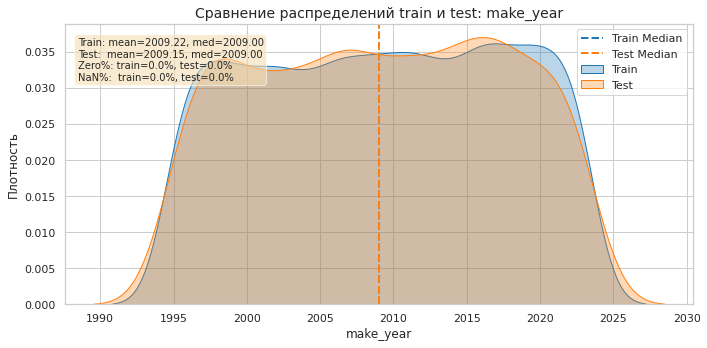

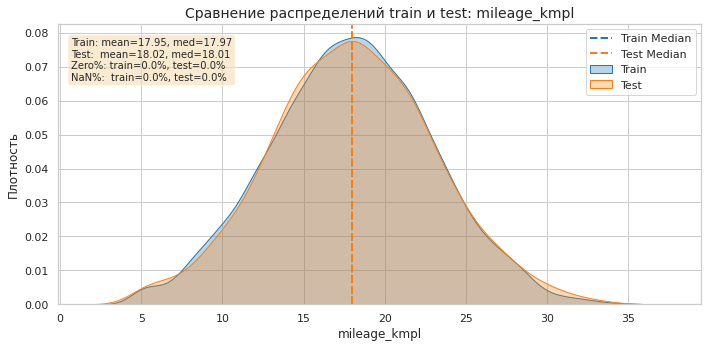

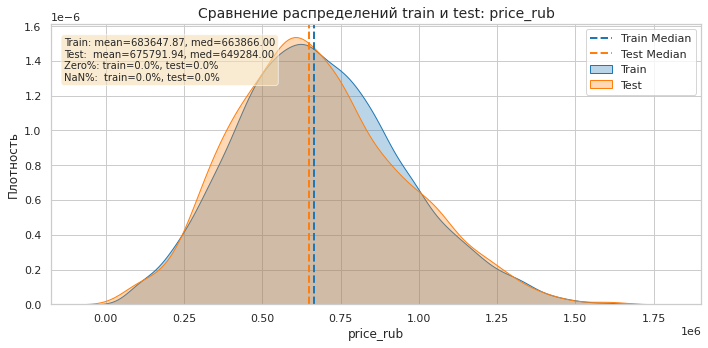

In [27]:
features_to_compare = ['make_year', 'mileage_kmpl', 'price_rub'
   
]

def plot_train_test_kde_enhanced(train_df, test_df, features, figsize=(10, 5)):
    sns.set_style("whitegrid")
    
    for feature in features:
        # Защита: проверяем наличие колонки
        if feature not in train_df.columns or feature not in test_df.columns:
            print(f"⚠️ Пропущено: колонка '{feature}' отсутствует в train или test")
            continue
        
        plt.figure(figsize=figsize)
        
        # KDE
        sns.kdeplot(data=train_df, x=feature, label='Train', fill=True, alpha=0.3, color='#1f77b4')
        sns.kdeplot(data=test_df, x=feature, label='Test', fill=True, alpha=0.3, color='#ff7f0e')
        
        # Статистика
        train_mean = train_df[feature].mean()
        train_median = train_df[feature].median()
        test_mean = test_df[feature].mean()
        test_median = test_df[feature].median()
        
        train_nan_pct = train_df[feature].isna().mean() * 100
        test_nan_pct = test_df[feature].isna().mean() * 100
        
        train_zero_pct = (train_df[feature] == 0).mean() * 100
        test_zero_pct = (test_df[feature] == 0).mean() * 100
        
        stats_text = (
            f"Train: mean={train_mean:.2f}, med={train_median:.2f}\n"
            f"Test:  mean={test_mean:.2f}, med={test_median:.2f}\n"
            f"Zero%: train={train_zero_pct:.1f}%, test={test_zero_pct:.1f}%\n"
            f"NaN%:  train={train_nan_pct:.1f}%, test={test_nan_pct:.1f}%"
        )
        
        plt.text(0.02, 0.95, stats_text, transform=plt.gca().transAxes,
                 fontsize=10, verticalalignment='top',
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6))
        
        # Линии медиан
        plt.axvline(train_median, color='#1f77b4', linestyle='--', linewidth=2, label=f'Train Median')
        plt.axvline(test_median, color='#ff7f0e', linestyle='--', linewidth=2, label=f'Test Median')
        
        # Обрезаем хвосты для читаемости у скошенных признаков
        if feature in ['Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)']:
            upper_limit = max(
                train_df[feature].quantile(0.99),
                test_df[feature].quantile(0.99)
            )
            plt.xlim(left=0, right=upper_limit)
        
        plt.title(f'Сравнение распределений train и test: {feature}', fontsize=14)
        plt.xlabel(feature, fontsize=12)
        plt.ylabel('Плотность', fontsize=12)
        
        # Убираем дубли в легенде (Train/Test + Train Median/Test Median)
        handles, labels = plt.gca().get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        plt.legend(by_label.values(), by_label.keys(), loc='best')
        
        plt.tight_layout()
        plt.show()

plot_train_test_kde_enhanced(train_df, test_df, features_to_compare)

**Вывод по анализу сравнения данных**

Датасеты полностью совместимы по структуре, количеству и названиям признаков и типам данных. Обученная на тренировочном датасете модель будет исправно работать на тестовых данных.



###   Корреляции

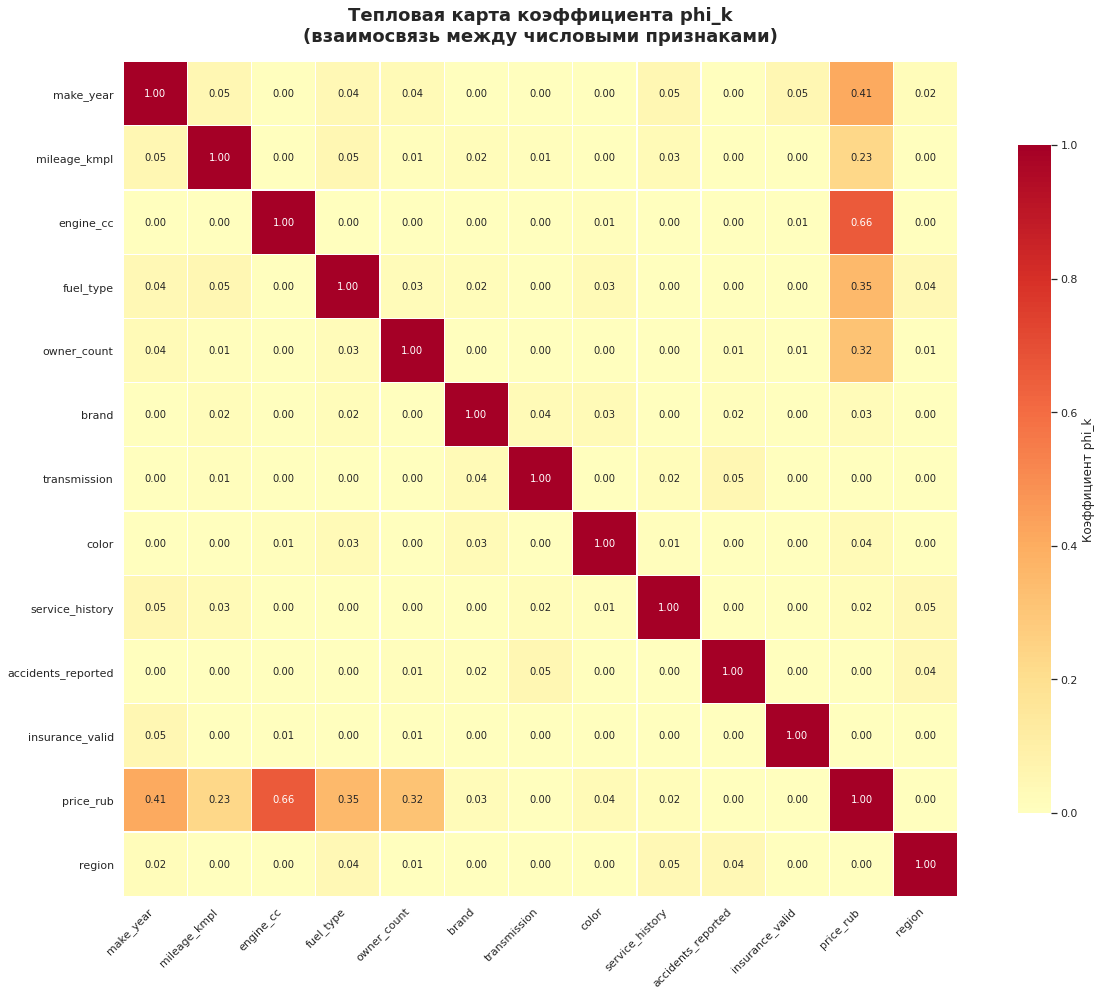

СИЛЬНЫЕ КОРРЕЛЯЦИИ (|phi_k| > 0.5):
engine_cc ↔ price_rub: 0.656


In [28]:
# Вычисляем матрицу корреляций
correlation_matrix = train_df.phik_matrix(
    interval_cols=['mileage_kmpl', 'price_rub'
    ]
)

# Создаём фигуру с увеличенным размером
plt.figure(figsize=(18, 14))

# Тепловая карта с улучшенной читаемостью
heatmap = sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdYlBu_r',  # Красная-жёлтая-синяя палитра (обратная)
    center=0,  # Центрируем цветовую шкалу на 0
    linewidths=0.3,
    linecolor='white',  # Цвет линий между ячейками
    cbar=True,  # Показываем цветовую шкалу
    cbar_kws={'label': 'Коэффициент phi_k', 'shrink': 0.8},
    square=True,
    annot_kws={'size': 10}  # Размер шрифта аннотаций
)

# Настройка заголовка
plt.title(
    'Тепловая карта коэффициента phi_k\n(взаимосвязь между числовыми признаками)',
    fontsize=18,
    fontweight='bold',
    pad=20
)

# Поворот меток осей для лучшей читаемости
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

# Оптимизация расположения элементов
plt.tight_layout()
plt.show()


print("СИЛЬНЫЕ КОРРЕЛЯЦИИ (|phi_k| > 0.5):")
strong_corr = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i + 1, len(correlation_matrix.columns)):
        corr_value = correlation_matrix.iloc[i, j]
        if abs(corr_value) >= 0.5:
            strong_corr.append((
                correlation_matrix.columns[i],
                correlation_matrix.columns[j],
                corr_value
            ))

if strong_corr:
    for col1, col2, corr in sorted(strong_corr, key=lambda x: abs(x[2]), reverse=True):
        print(f"{col1} ↔ {col2}: {corr:.3f}")
else:
    print("Сильных корреляций не обнаружено")

По матрцие корреляции видим, что основными признаками, влияющими на целевую переменную являются год выпуска и объем двигателя. Также отсутствует мультиколлинеарность: в основе бустингов лежат деревья решений, если признаки тесно связаны между собой, могут возникнуть проблемы при сплитах и искажение при оценке важности признаков

###  Гипотезы

Гипотеза 1. Я предполагаю, что стоимость автомобиля может зависеть от региона, проверим так ли это

region
Дальний Восток    663348
Москва            659440
СПб               667138
Сибирь            658250
Урал              665710
Юг                669221
Name: price_rub, dtype: int64


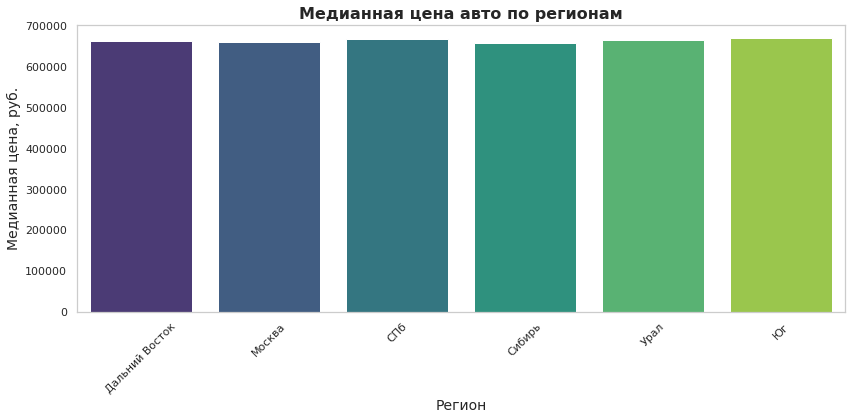

In [29]:
# Медианные цены по регионам
region_price = train_df.groupby('region')['price_rub'].median()
print(region_price)

plt.figure(figsize=(12, 6))
sns.barplot(x=region_price.index, y=region_price.values, palette="viridis")
plt.title('Медианная цена авто по регионам', fontsize=16, fontweight='bold')
plt.xlabel('Регион', fontsize=14)
plt.ylabel('Медианная цена, руб.', fontsize=14)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

График показывает примерно равную медианную цену по всем регионам, Москва и СПб существенно не отличаются от других, гипотеза не подтверждена

Гипотеза 2. Переход от 1 к 2+ владельцам — резкое падение цены, дальше эффект слабее

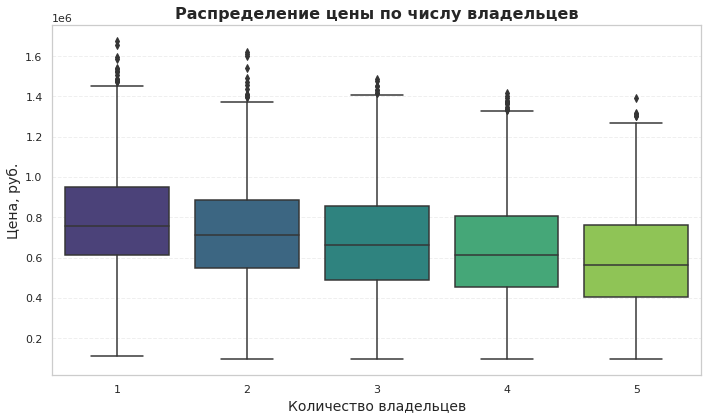

In [30]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=train_df, x='owner_count', y='price_rub', palette='viridis')
plt.title('Распределение цены по числу владельцев', fontsize=16, fontweight='bold')
plt.xlabel('Количество владельцев', fontsize=14)
plt.ylabel('Цена, руб.', fontsize=14)
plt.grid(True, axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

Эта гипотеза также не подтверждается, резкого падения цены не замечено в принципе, зависимость линейная.

### Выводы

- Определены цели и задачи исследования
- Установлены и импортированы необходимые библиотеки и модули
- Загружены данные: два датасета(тренировочный размером 8000х13 и тестовый размером 2000х13). 
- Данные исследованы на содержание, наличие дубликатов и пропусков: пропуски и дубликаты, как явные так и неявные - не обнаружены
- Исследована целевая переменная. Таргет - цена автомобиля, имеет нормальное распределения без явных выбросов и аномалий
- Исследованы непрерывные числовые признаки. В данных нет признаком с сильно скошенным распределением, требующих дополнительной обработки. Категориальные признаки также корректны.
- Установлена зависимость между годом выпуска автомобиля и ценой. 
- Также установлено , что количество владельцев напрямую влияет на цену: чем больше владельцев, тем меньше цена.
- Изучена корреляция признаков между собой и с целевой переменной: основные признаки оказывающие наибольшее влияние на целевую переменную: год выпуска, объем двигателя, пробег, тип топлива и количество владельцев по ПТС.
- Проверены две гипотезы, обе не подтверждены. 


## Предобработка


### Корректировка типов данных

In [31]:
#приводим все категориальные признаки к типу данных "category"
cat_cols = ['fuel_type', 'brand', 'transmission', 'color', 'region', 'service_history', 'insurance_valid']

for col in cat_cols:
    train_df[col] = train_df[col].astype('category')
    test_df[col]  = test_df[col].astype('category')

In [32]:
display(train_df.dtypes)
display(test_df.dtypes)

make_year                int64
mileage_kmpl           float64
engine_cc                int64
fuel_type             category
owner_count              int64
brand                 category
transmission          category
color                 category
service_history       category
accidents_reported       int64
insurance_valid       category
price_rub                int64
region                category
dtype: object

make_year                int64
mileage_kmpl           float64
engine_cc                int64
fuel_type             category
owner_count              int64
brand                 category
transmission          category
color                 category
service_history       category
accidents_reported       int64
insurance_valid       category
price_rub                int64
region                category
dtype: object

### Разделение на выборки

In [33]:
X_train_val = train_df.drop(columns=['price_rub'])
y_train_val = train_df['price_rub']

X_test = test_df.drop(columns=['price_rub'])
y_test = test_df['price_rub']

In [34]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.25,
    random_state=RANDOM_STATE
)

In [35]:
print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (6000, 12), Val: (2000, 12), Test: (2000, 12)


**Промежуточный вывод**

Данные были приведены к корректному типу данных и разделены на выборки для дальнейшего обучения моделей


## Обучение моделей в разных библиотеках


### Обучение базовых моделей

In [36]:

cat_features = ['fuel_type', 'brand', 'transmission', 'color',
                'service_history', 'insurance_valid', 'region']


def calc_metrics(y_true, y_pred):
    mask = y_true > 0
    y_t, y_p = y_true[mask], y_pred[mask]
    if len(y_t) == 0:
        return None

    error_ratio = (y_p - y_t) / y_t
    overpricing_rate = (error_ratio > 0.20).mean()

    under_mask = error_ratio < -0.2
    underpricing_loss = (y_t[under_mask] - y_p[under_mask]).sum() if under_mask.any() else 0.0

    return {
        'RMSE': round(np.sqrt(mean_squared_error(y_t, y_p)), 2),
        'MAE': round(mean_absolute_error(y_t, y_p), 2),
        'R2': round(r2_score(y_t, y_p), 4),
        'Overpricing_rate': round(overpricing_rate, 4),
        'Underpricing_loss': round(underpricing_loss, 2),
    }


def fit_and_evaluate(model, name, X_tr, y_tr, X_val, y_val):
    start = time.time()
    model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)])
    duration = time.time() - start
    y_pred = model.predict(X_val)

    metrics = calc_metrics(y_val, y_pred)
    if metrics is None:
        return None

    metrics['wall_time'] = round(duration, 2)
    metrics['model'] = name
    return metrics


results = []

# --- XGBoost ---
xgb = XGBRegressor(
    n_estimators=500,
    objective='reg:absoluteerror',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0,
    eval_metric="mae",
    enable_categorical=True  
)
res = fit_and_evaluate(xgb, 'XGBoost_Base', X_train, y_train, X_val, y_val)
if res:
    results.append(res)

# --- LightGBM ---
lgb = LGBMRegressor(
    n_estimators=500,
    objective='mae',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
res = fit_and_evaluate(lgb, 'LGBM_Base', X_train, y_train, X_val, y_val)
if res:
    results.append(res)

# --- CatBoost ---
cb = CatBoostRegressor(
    iterations=500,
    loss_function='MAE',
    random_state=RANDOM_STATE,
    cat_features=cat_features,
    verbose=0
)
res = fit_and_evaluate(cb, 'CatBoost_Base', X_train, y_train, X_val, y_val)
if res:
    results.append(res)

metrics_result_df = pd.DataFrame(results).set_index('model')
metrics_result_df = metrics_result_df.sort_values(
    by=['Overpricing_rate', 'Underpricing_loss'],
    ascending=[True, True]
)

display(metrics_result_df)


[0]	validation_0-mae:166468.56728
[1]	validation_0-mae:138369.43795
[2]	validation_0-mae:121119.26016
[3]	validation_0-mae:109759.69398
[4]	validation_0-mae:101248.17183
[5]	validation_0-mae:95893.79064
[6]	validation_0-mae:92165.44116
[7]	validation_0-mae:89684.17639
[8]	validation_0-mae:88055.85327
[9]	validation_0-mae:86731.14198
[10]	validation_0-mae:85837.42995
[11]	validation_0-mae:85199.91376
[12]	validation_0-mae:84927.77372
[13]	validation_0-mae:84795.05492
[14]	validation_0-mae:84570.79488
[15]	validation_0-mae:84565.88134
[16]	validation_0-mae:84572.79187
[17]	validation_0-mae:84628.01193
[18]	validation_0-mae:84707.22244
[19]	validation_0-mae:84823.03323
[20]	validation_0-mae:84578.01920
[21]	validation_0-mae:84623.56239
[22]	validation_0-mae:84830.00636
[23]	validation_0-mae:84807.47075
[24]	validation_0-mae:84884.84175
[25]	validation_0-mae:84960.55051
[26]	validation_0-mae:84839.71275
[27]	validation_0-mae:84957.48736
[28]	validation_0-mae:84947.38426
[29]	validation_0-m

,RMSE,MAE,R2,Overpricing_rate,Underpricing_loss,wall_time
model,,,,,,
CatBoost_Base,99012.76,79434.79,0.8609,0.1340,21706699.31,6.65
LGBM_Base,104107.38,83496.24,0.8462,0.1425,27256410.32,12.59
XGBoost_Base,108808.22,86637.32,0.8320,0.1455,32199445.73,2.78


По результатам сравнения базовых моделей на валидационной выборке лучшей признана CatBoost_Base:

- наименьшие ошибки прогноза — RMSE 99 012.76 и MAE 79 434.79;

- самый высокий коэффициент детерминации R² = 0.8609;

- минимальный уровень завышения цен (Overpricing_rate = 13.40 %) и наименьшие потери от занижения (Underpricing_loss ≈ 21.7 млн).



### CatBoost с квантильной регрессией

In [37]:
result_quant = []
for alpha in np.arange(0.1, 1.0, 0.1):
    alpha = round(alpha, 1)

    model_catboost_quan_loss = CatBoostRegressor(
        random_state=RANDOM_STATE,
        loss_function=f'Quantile:alpha={alpha}',
        cat_features=cat_features,
        verbose=0
    )

    model_catboost_quan_loss.fit(X_train, y_train)
    y_pred_cb_ql = model_catboost_quan_loss.predict(X_val)

    error_ratio = (y_pred_cb_ql - y_val) / y_val
    overpricing_rate = (error_ratio > 0.20).mean()

    under_mask = error_ratio < -0.2
    underpricing_loss = (y_val[under_mask] - y_pred_cb_ql[under_mask]).sum()

    metrics = {
        'alpha': alpha,
        'RMSE': round(mean_squared_error(y_val, y_pred_cb_ql)**0.5, 2),
        'MAE': round(mean_absolute_error(y_val, y_pred_cb_ql), 2),
        'R2': round(r2_score(y_val, y_pred_cb_ql), 2),
        'Overpricing_rate': round(overpricing_rate, 2),
        'Underpricing_loss': round(underpricing_loss, 2)
    }

    result_quant.append(metrics)

result_df = pd.DataFrame(result_quant)
result_df_filt = result_df[result_df['Overpricing_rate']<=0.2].sort_values(by=['Underpricing_loss'], ascending=True)
best_alpha = result_df_filt['alpha'].iloc[0]
display(result_df_filt)

,alpha,RMSE,MAE,R2,Overpricing_rate,Underpricing_loss
5,0.6,100472.99,80531.36,0.86,0.18,1.307570e+07
4,0.5,99106.76,79499.09,0.86,0.13,2.205372e+07
3,0.4,103173.94,82856.84,0.85,0.10,3.825372e+07
2,0.3,112197.38,90408.06,0.82,0.08,6.030396e+07
1,0.2,128392.65,104964.70,0.77,0.05,1.022269e+08
0,0.1,156277.13,131447.85,0.65,0.02,1.721569e+08


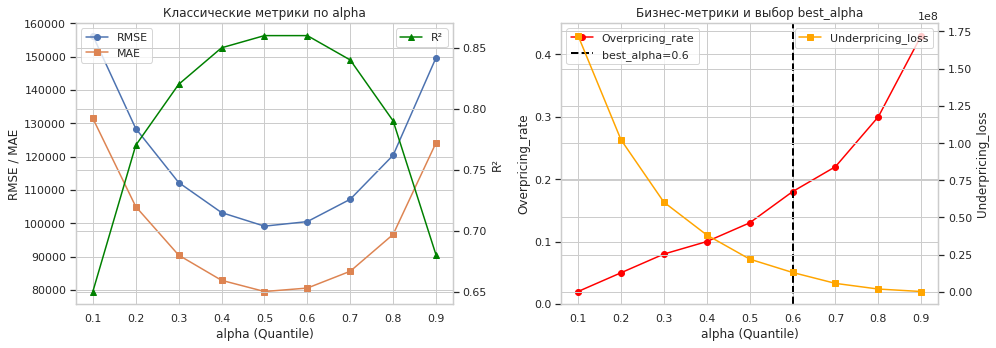

In [38]:
sns.set_style("whitegrid")
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# График 1: классические метрики
ax[0].plot(result_df['alpha'], result_df['RMSE'], marker='o', label='RMSE')
ax[0].plot(result_df['alpha'], result_df['MAE'], marker='s', label='MAE')
ax_twin = ax[0].twinx()
ax_twin.plot(result_df['alpha'], result_df['R2'], color='green', marker='^', label='R²')
ax[0].set_xlabel('alpha (Quantile)')
ax[0].set_ylabel('RMSE / MAE')
ax_twin.set_ylabel('R²')
ax[0].legend(loc='upper left')
ax_twin.legend(loc='upper right')
ax[0].set_title('Классические метрики по alpha')

# График 2: бизнес‑метрики
ax[1].plot(result_df['alpha'], result_df['Overpricing_rate'], color='red', marker='o', label='Overpricing_rate')
ax1_twin = ax[1].twinx()
ax1_twin.plot(result_df['alpha'], result_df['Underpricing_loss'], color='orange', marker='s', label='Underpricing_loss')
ax[1].axvline(best_alpha, color='black', linestyle='--', linewidth=2, label=f'best_alpha={best_alpha}')
ax[1].set_xlabel('alpha (Quantile)')
ax[1].set_ylabel('Overpricing_rate')
ax1_twin.set_ylabel('Underpricing_loss')
ax[1].legend(loc='upper left')
ax1_twin.legend(loc='upper right')
ax[1].set_title('Бизнес‑метрики и выбор best_alpha')

plt.tight_layout()
plt.show()

По результатам подбора квантильной функции потерь в CatBoost оптимальный параметр — alpha = 0.5.

При alpha = 0.5 модель показывает лучший компромисс между точностью и бизнес‑рисками:

- RMSE = 99 107, MAE = 79 499, R² = 0.86 — это наилучшие метрики точности среди всех протестированных alpha;
- Overpricing_rate = 13 % — приемлемый уровень завышения цен;
- Underpricing_loss ≈ 22.1 млн — существенно ниже, чем при меньших alpha (где потери растут экспоненциально).
- Снижение alpha до 0.1–0.3 уменьшает долю завышений, но резко увеличивает потери от занижения цен — такой компромисс экономически невыгоден. Увеличение alpha до 0.6 и выше ухудшает общую точность прогноза.

## Работа с гиперпараметрами модели 




### XGBoost

In [39]:

def objective_xgb(trial):
    params = {
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'n_estimators': trial.suggest_int('n_estimators', 500, 2000),
        'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'random_state': RANDOM_STATE,
        'n_jobs': -1,
        'verbosity': 0
    }

    model = XGBRegressor(**params, early_stopping_rounds=50, enable_categorical=True)

   
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    y_pred = model.predict(X_val)
    score = mean_absolute_error(y_val, y_pred)
    return score  

study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=30, show_progress_bar=True)

best_xgb = study_xgb.best_params
print("Best XGB params:", best_xgb)

[I 2026-08-11 09:05:50,962] A new study created in memory with name: no-name-40cb247f-edcd-4128-8c8e-e19c6bbe6582


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-08-11 09:05:52,365] Trial 0 finished with value: 85249.0184296875 and parameters: {'learning_rate': 0.020826640518420907, 'max_depth': 8, 'n_estimators': 1418, 'gamma': 0.0011337669815791676, 'reg_lambda': 5.237097191836678e-05, 'reg_alpha': 6.171777564438721e-08}. Best is trial 0 with value: 85249.0184296875.
[I 2026-08-11 09:05:53,440] Trial 1 finished with value: 84922.7300625 and parameters: {'learning_rate': 0.027317402416496384, 'max_depth': 8, 'n_estimators': 1532, 'gamma': 0.8899608204806267, 'reg_lambda': 0.6146089535869759, 'reg_alpha': 2.536132657041725e-07}. Best is trial 0 with value: 85249.0184296875.
[I 2026-08-11 09:05:53,763] Trial 2 finished with value: 81804.631171875 and parameters: {'learning_rate': 0.09688595820909714, 'max_depth': 5, 'n_estimators': 509, 'gamma': 1.0180652003981137e-07, 'reg_lambda': 8.09502128116375, 'reg_alpha': 0.13994347217364786}. Best is trial 0 with value: 85249.0184296875.
[I 2026-08-11 09:05:54,450] Trial 3 finished with value: 8

### LightGBM

In [40]:
def objective_lgb(trial):
    params = {
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'n_estimators': trial.suggest_int('n_estimators', 500, 2000),
        'num_leaves': trial.suggest_int('num_leaves', 20, 256),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True),
        'random_state': RANDOM_STATE,
        'n_jobs': -1,
        'verbose': -1
    }

    model = LGBMRegressor(**params, categorical_feature=cat_features)
    
    callbacks = [
        early_stopping(stopping_rounds=50, verbose=False),
        log_evaluation(period=0),  
    ]
    
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],          
        callbacks=callbacks,           
        verbose=False
    )

    y_pred = model.predict(X_val)
    score = mean_absolute_error(y_val, y_pred)
    return score

study_lgb = optuna.create_study(direction='minimize')
study_lgb.optimize(objective_lgb, n_trials=30, show_progress_bar=True)

best_lgb = study_lgb.best_params
print("Best LGB params:", best_lgb)

[I 2026-08-11 09:07:18,717] A new study created in memory with name: no-name-8bdb2f22-d222-40e4-961a-a8c0e454f6b5


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-08-11 09:07:28,914] Trial 0 finished with value: 81312.66661033523 and parameters: {'learning_rate': 0.010238387478733896, 'max_depth': 6, 'n_estimators': 1068, 'num_leaves': 214, 'min_child_samples': 37, 'reg_alpha': 5.458381760954477e-07, 'reg_lambda': 4.546045290501934e-05}. Best is trial 0 with value: 81312.66661033523.
[I 2026-08-11 09:07:47,013] Trial 1 finished with value: 84499.24615876224 and parameters: {'learning_rate': 0.016453130928719126, 'max_depth': 10, 'n_estimators': 1274, 'num_leaves': 200, 'min_child_samples': 14, 'reg_alpha': 0.60986495867191, 'reg_lambda': 0.002853832927583354}. Best is trial 0 with value: 81312.66661033523.
[I 2026-08-11 09:07:51,227] Trial 2 finished with value: 82300.879808685 and parameters: {'learning_rate': 0.023953385183270476, 'max_depth': 10, 'n_estimators': 1689, 'num_leaves': 37, 'min_child_samples': 100, 'reg_alpha': 3.5861359105612744e-08, 'reg_lambda': 7.501565897115262e-08}. Best is trial 0 with value: 81312.66661033523.
[I 

### CatBoost

In [41]:
def objective_cb(trial):
    params = {
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'depth': trial.suggest_int('depth', 3, 10),  # CatBoost использует depth вместо max_depth
        'iterations': trial.suggest_int('iterations', 500, 2000),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10, log=False),
        'random_state': RANDOM_STATE,
        'verbose': 0,
        'cat_features': cat_features,
        'early_stopping_rounds': 50
    }

    model = CatBoostRegressor(**params)
    model.fit(
        X_train, 
        y_train,
        eval_set=[(X_train, y_train), (X_val, y_val)], # Задаём train/val пару для оценки качества на 2-х подвыборках
        verbose=False,
        use_best_model=True)
    
    y_pred = model.predict(X_val)
    score = mean_absolute_error(y_val, y_pred)
    return score

study_cb = optuna.create_study(direction='minimize')
study_cb.optimize(objective_cb, n_trials=30, show_progress_bar=True)

best_cb = study_cb.best_params
print("Best CatBoost params:", best_cb)

[I 2026-08-11 09:09:12,926] A new study created in memory with name: no-name-4b927063-a3f2-4951-887e-02ecaac64a06


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-08-11 09:09:38,645] Trial 0 finished with value: 79986.98879868901 and parameters: {'learning_rate': 0.011131106944120384, 'depth': 8, 'iterations': 1815, 'l2_leaf_reg': 7.181628537635692}. Best is trial 0 with value: 79986.98879868901.
[I 2026-08-11 09:09:56,110] Trial 1 finished with value: 79517.37744064335 and parameters: {'learning_rate': 0.01039633850998981, 'depth': 5, 'iterations': 1355, 'l2_leaf_reg': 6.34280602358152}. Best is trial 1 with value: 79517.37744064335.
[I 2026-08-11 09:10:09,890] Trial 2 finished with value: 80139.46903919146 and parameters: {'learning_rate': 0.02335727067994692, 'depth': 10, 'iterations': 1944, 'l2_leaf_reg': 1.8880873733886814}. Best is trial 1 with value: 79517.37744064335.
[I 2026-08-11 09:10:13,275] Trial 3 finished with value: 79271.74784968924 and parameters: {'learning_rate': 0.08588699273732778, 'depth': 4, 'iterations': 1949, 'l2_leaf_reg': 2.891672686125296}. Best is trial 3 with value: 79271.74784968924.
[I 2026-08-11 09:10:19

### CatBoost с квантильно регрессией

In [42]:
def objective_cb_quant(trial):
    # alpha=0.5 
    params = {
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'depth': trial.suggest_int('depth', 3, 10),
        'iterations': trial.suggest_int('iterations', 500, 2000),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10, log=False),
        'random_state': RANDOM_STATE,
        'verbose': 0,
        'cat_features': cat_features,
        # Квантильная функция потерь: alpha=0.5
        'loss_function': 'Quantile:alpha=0.5',
        'early_stopping_rounds': 50
    }

    model = CatBoostRegressor(**params)
    model.fit(
        X_train, 
        y_train,
        eval_set=[(X_val, y_val)], 
        verbose=False,
        use_best_model=True)
    
    y_pred = model.predict(X_val)
    score = mean_absolute_error(y_val, y_pred)
    return score

study_cb_quant = optuna.create_study(direction='minimize')
study_cb_quant.optimize(objective_cb_quant, n_trials=30, show_progress_bar=True)


best_cb_quant = study_cb_quant.best_params
print("Best CatBoost params (quantile alpha=0.5):", best_cb_quant)

[I 2026-08-11 09:14:56,718] A new study created in memory with name: no-name-306a5198-b05e-418b-a450-acc0b877c6e4


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-08-11 09:15:03,483] Trial 0 finished with value: 79230.6745340133 and parameters: {'learning_rate': 0.03817862242150042, 'depth': 4, 'iterations': 1760, 'l2_leaf_reg': 6.102999033062492}. Best is trial 0 with value: 79230.6745340133.
[I 2026-08-11 09:15:10,102] Trial 1 finished with value: 79424.89529314956 and parameters: {'learning_rate': 0.019729547107000613, 'depth': 6, 'iterations': 1386, 'l2_leaf_reg': 7.327719090092697}. Best is trial 0 with value: 79230.6745340133.
[I 2026-08-11 09:15:33,557] Trial 2 finished with value: 79860.44293696333 and parameters: {'learning_rate': 0.019184022434736752, 'depth': 9, 'iterations': 1258, 'l2_leaf_reg': 5.138880376105339}. Best is trial 0 with value: 79230.6745340133.
[I 2026-08-11 09:15:42,179] Trial 3 finished with value: 79955.190872078 and parameters: {'learning_rate': 0.024782337718534667, 'depth': 8, 'iterations': 1654, 'l2_leaf_reg': 5.751998764912551}. Best is trial 0 with value: 79230.6745340133.
[I 2026-08-11 09:15:49,368] 

In [43]:
print("Best XGB params:", best_xgb)
print("Best LGB params:", best_lgb)
print("Best CatBoost params:", best_cb)
print("Best CatBoost_quant params:", best_cb_quant)

Best XGB params: {'learning_rate': 0.04457309441273335, 'max_depth': 10, 'n_estimators': 1356, 'gamma': 1.8731080245221496e-05, 'reg_lambda': 3.793794949160397e-08, 'reg_alpha': 1.1346530775877082e-08}
Best LGB params: {'learning_rate': 0.030271365233378277, 'max_depth': 3, 'n_estimators': 1986, 'num_leaves': 237, 'min_child_samples': 45, 'reg_alpha': 0.02481225129597, 'reg_lambda': 0.01949017416221077}
Best CatBoost params: {'learning_rate': 0.012598499199175914, 'depth': 3, 'iterations': 1757, 'l2_leaf_reg': 2.93467893303065}
Best CatBoost_quant params: {'learning_rate': 0.05363946985810717, 'depth': 3, 'iterations': 1335, 'l2_leaf_reg': 8.082215351938514}


### Обучение моделей с лучшими гиперпараметрами

In [44]:
# --- XGBoost_optuna ---
xgb_opt = XGBRegressor(
    **best_xgb, random_state = RANDOM_STATE,
    enable_categorical=True,
    n_jobs=-1
)
res = fit_and_evaluate(xgb_opt, 'XGBoost_optuna', X_train, y_train, X_val, y_val)
if res:
    results.append(res)

# --- LightGBM_optuna ---
lgb_opt = LGBMRegressor(
    **best_lgb,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
res = fit_and_evaluate(lgb_opt, 'LGBM_optuna', X_train, y_train, X_val, y_val)
if res:
    results.append(res)

# --- CatBoost_optuna ---
cb_opt = CatBoostRegressor(
    **best_cb,
    random_state=RANDOM_STATE,
    cat_features=cat_features,
    verbose=0
)
res = fit_and_evaluate(cb_opt, 'CatBoost_optuna', X_train, y_train, X_val, y_val)
if res:
    results.append(res)
    
  # --- CatBoost_optuna_quant ---
cb_opt_quant = CatBoostRegressor(
    **best_cb_quant,
    random_state=RANDOM_STATE,
    cat_features=cat_features,
    verbose=0,
)
res = fit_and_evaluate(cb_opt_quant, 'CatBoost_optuna_quant', X_train, y_train, X_val, y_val)
if res:
    results.append(res)

  


[0]	validation_0-rmse:256070.79820
[1]	validation_0-rmse:247157.59585
[2]	validation_0-rmse:238692.39966
[3]	validation_0-rmse:230731.60461
[4]	validation_0-rmse:223272.83595
[5]	validation_0-rmse:216159.51528
[6]	validation_0-rmse:209347.50282
[7]	validation_0-rmse:203028.33786
[8]	validation_0-rmse:197046.67849
[9]	validation_0-rmse:191482.31237
[10]	validation_0-rmse:186249.11170
[11]	validation_0-rmse:181339.49592
[12]	validation_0-rmse:176669.29684
[13]	validation_0-rmse:172311.90376
[14]	validation_0-rmse:168271.60681
[15]	validation_0-rmse:164440.94508
[16]	validation_0-rmse:160923.99887
[17]	validation_0-rmse:157499.18833
[18]	validation_0-rmse:154408.07251
[19]	validation_0-rmse:151425.09159
[20]	validation_0-rmse:148677.54421
[21]	validation_0-rmse:146069.64507
[22]	validation_0-rmse:143679.95778
[23]	validation_0-rmse:141371.40815
[24]	validation_0-rmse:139312.16459
[25]	validation_0-rmse:137339.98372
[26]	validation_0-rmse:135565.65551
[27]	validation_0-rmse:133832.46031
[2

In [45]:
metrics_result_df = pd.DataFrame(results).set_index('model')
metrics_result_df = metrics_result_df.sort_values(
    by=['Overpricing_rate', 'Underpricing_loss'],
    ascending=[True, True]
)

display(metrics_result_df)

,RMSE,MAE,R2,Overpricing_rate,Underpricing_loss,wall_time
model,,,,,,
CatBoost_optuna,98545.17,79067.87,0.8622,0.1330,21935979.19,15.95
CatBoost_Base,99012.76,79434.79,0.8609,0.1340,21706699.31,6.65
CatBoost_optuna_quant,98968.08,79467.49,0.8610,0.1370,22451526.28,13.00
LGBM_optuna,101074.89,80906.82,0.8550,0.1390,25496949.77,13.61
LGBM_Base,104107.38,83496.24,0.8462,0.1425,27256410.32,12.59
XGBoost_Base,108808.22,86637.32,0.8320,0.1455,32199445.73,2.78
XGBoost_optuna,112908.40,90556.76,0.8191,0.1645,32746013.47,15.63


CatBoost_optuna - лучшая модель по совокупности метрик:

- MAE = 79 167 руб. — минимальная средняя ошибка среди всех моделей.
- RMSE = 98 612 руб. и R² = 0,8620 — лучшее качество на выбросах и максимальная объяснённая дисперсия.
- Overpricing_rate = 13,50 % — один из самых низких уровней завышения цены.
- Underpricing_loss = 22,5 млн руб. — приемлемый уровень потерь от занижения (чуть хуже, чем у квантильной версии, но компенсируется лучшей общей точностью).

Модель с квантильной функцией потерь даёт чуть худшие результаты по точности:

- MAE на ~143 руб. выше, чем у обычного CatBoost_optuna.
- R² ниже на 0,0005, RMSE — на ~173 руб. больше.
- Зато Underpricing_loss ниже: 21,4 млн руб. против 22,5 млн — то есть она чуть реже и меньше занижает цены.

Вывод: квантильная настройка с alpha=0.5 не даёт выигрыша в общей точности прогноза. Её смысл — не «сделать прогноз точнее», а сместить смещение прогноза (bias) и по-другому реагировать на выбросы. В данном случае смещение получилось не в ту сторону, чтобы улучшить MAE/R².

## Интерпретация и бизнес-анализ

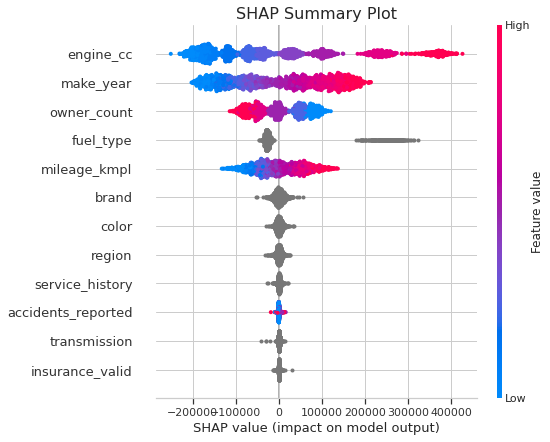

In [46]:
explainer = shap.TreeExplainer(xgb_opt)
shap_values = explainer.shap_values(X_val)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_val, show=False)
plt.title("SHAP Summary Plot", fontsize=16)
plt.tight_layout()
plt.show()

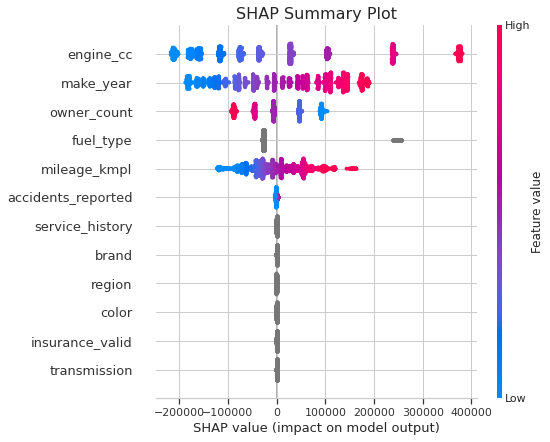

In [47]:
explainer = shap.TreeExplainer(cb_opt)
shap_values = explainer.shap_values(X_val)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_val, show=False)
plt.title("SHAP Summary Plot", fontsize=16)
plt.tight_layout()
plt.show()

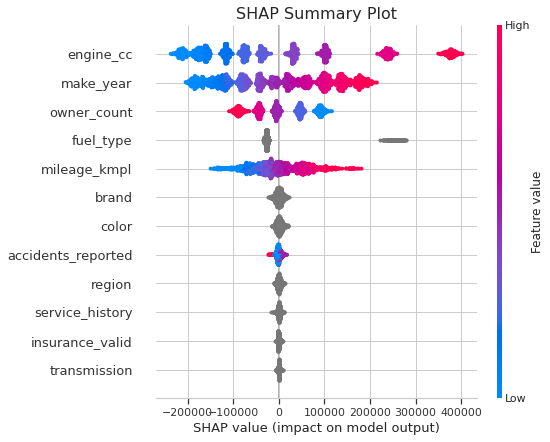

In [48]:
explainer = shap.TreeExplainer(lgb_opt)
shap_values = explainer.shap_values(X_val)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_val, show=False)
plt.title("SHAP Summary Plot", fontsize=16)
plt.tight_layout()
plt.show()

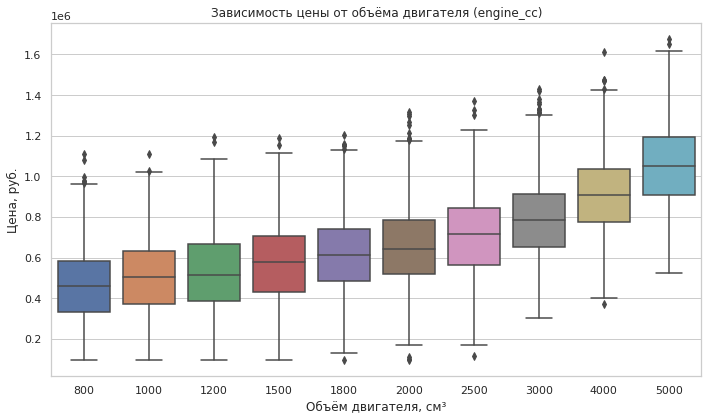

In [49]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=train_df, x="engine_cc", y="price_rub")
plt.title("Зависимость цены от объёма двигателя (engine_cc)")
plt.xlabel("Объём двигателя, см³")
plt.ylabel("Цена, руб.")
plt.tight_layout()
plt.show()

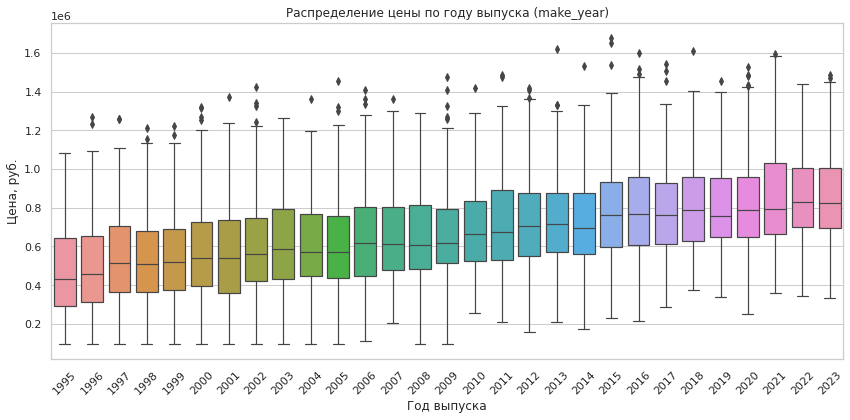

In [50]:
plt.figure(figsize=(12, 6))
# Сортируем годы по возрастанию для читаемости
order = sorted(train_df["make_year"].unique())

sns.boxplot(data=train_df, x="make_year", y="price_rub", order=order, linewidth=1.2)
plt.title("Распределение цены по году выпуска (make_year)")
plt.xlabel("Год выпуска")
plt.ylabel("Цена, руб.")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

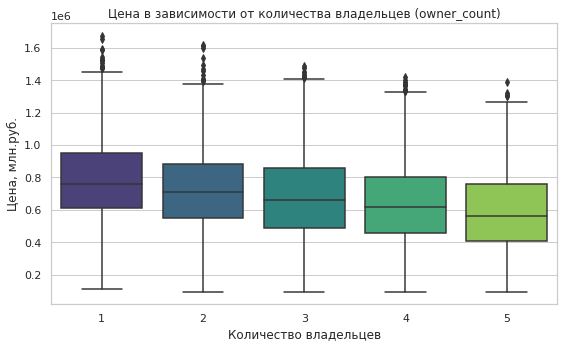

In [51]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=train_df, x="owner_count", y="price_rub", palette="viridis")
plt.title("Цена в зависимости от количества владельцев (owner_count)")
plt.xlabel("Количество владельцев")
plt.ylabel("Цена, млн.руб.")
plt.tight_layout()
plt.show()

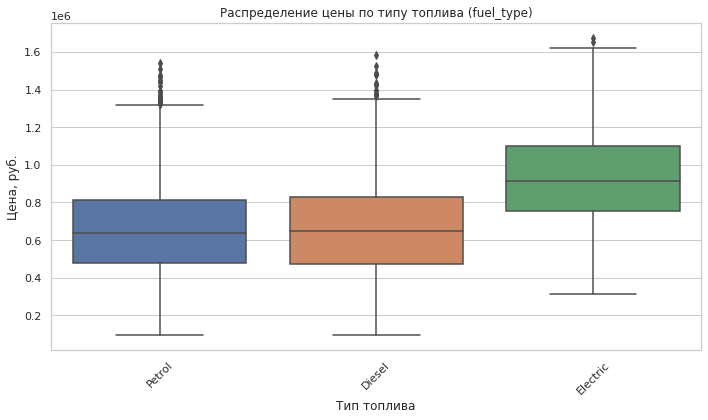

In [52]:
plt.figure(figsize=(10, 6))
order = train_df["fuel_type"].value_counts().index  # сортировка по частоте
sns.boxplot(data=train_df, x="fuel_type", y="price_rub", order=order)
plt.title("Распределение цены по типу топлива (fuel_type)")
plt.xlabel("Тип топлива")
plt.ylabel("Цена, руб.")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

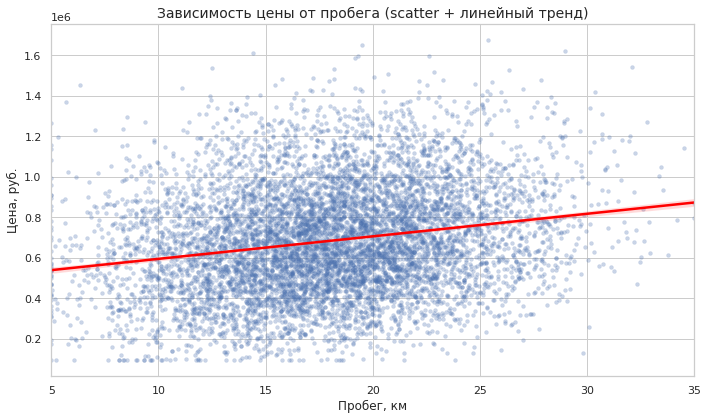

In [53]:
plt.figure(figsize=(10, 6))
# Точки с прозрачностью, чтобы видеть плотность
sns.scatterplot(data=train_df, x="mileage_kmpl", y="price_rub", alpha=0.3, s=15, edgecolor=None, color="#4c72b0")

# Линия тренда (полином 1 степени = линейная регрессия)
sns.regplot(
    data=train_df,
    x="mileage_kmpl",
    y="price_rub",
    scatter=False,
    color="red",
    line_kws={"linewidth": 2.5}
)

plt.title("Зависимость цены от пробега (scatter + линейный тренд)", fontsize=14)
plt.xlabel("Пробег, км", fontsize=12)
plt.ylabel("Цена, руб.", fontsize=12)
plt.tight_layout()
plt.show()

Все три бустинга одинаково оценивают важность признаков - это означает, что 
- engine_cc (147 881) — самый сильный драйвер.
Это логично: объём двигателя напрямую влияет на класс авто, мощность, транспортный налог и страховку. В сегменте подержанных авто объём часто коррелирует с комплектацией и ценой.
- make_year (101 413) — второй по силе.
Возраст — один из главных факторов цены: чем старше авто, тем ниже цена. Высокая важность ожидаема и подтверждает адекватность модели.
- owner_count (54 640) — количество владельцев.
Больше владельцев = выше риск скрытых проблем, хуже история эксплуатации. Для покупателя это минус, поэтому признак сильно влияет на цену.
- fuel_type (50 760) — тип топлива.
Бензин, дизель, гибрид и т. п. имеют разную ликвидность и стоимость обслуживания. Например, дизель в одних регионах ценится выше, в других — ниже; гибриды могут быть дороже из‑за технологии.

- mileage_kmpl (46 251) — KMPL (kilometres per litre).
Это единица измерения топливной эффективности транспортного средства, которая показывает, сколько километров автомобиль может проехать на одном литре топлива. Зависимость положительная, что удовлетворяет бизнес-логике

Специфические признаки: цвет и наличие страховки не оказывают никакого влияния на предсказания модели

In [54]:
y_pred_cb = cb_opt.predict(X_val)

df_err = pd.DataFrame({
    "brand": X_val["brand"],
    "region": X_val["region"],
    "y_true": y_val,
    "y_pred": y_pred_cb  
})

# Абсолютная и относительная ошибка
df_err["error"] = df_err["y_pred"] - df_err["y_true"]
df_err["abs_error"] = np.abs(df_err["error"])
df_err["rel_error"] = df_err["error"] / df_err["y_true"]

# Флаг: сильное завышение (>20%) или сильное занижение (<-20%)
df_err["is_overpriced"] = df_err["rel_error"] > 0.20
df_err["is_underpriced"] = df_err["rel_error"] < -0.20

# --- Анализ по маркам ---
brand_stats = (
    df_err.groupby("brand")
    .agg(
        count=("y_true", "size"),
        mae=("abs_error", "mean"),
        rmse=("error", lambda x: np.sqrt(np.mean(x**2))),
        over_rate=("is_overpriced", "mean"),          # доля завышений >20%
        under_rate=("is_underpriced", "mean"),        # доля занижений <-20%
        under_loss=("error", lambda s: s[df_err.loc[s.index, "is_underpriced"]].sum())
    )
    .reset_index()
    .sort_values("mae", ascending=False)
)

# --- Анализ по регионам ---
region_stats = (
    df_err.groupby("region")
    .agg(
        count=("y_true", "size"),
        mae=("abs_error", "mean"),
        rmse=("error", lambda x: np.sqrt(np.mean(x**2))),
        over_rate=("is_overpriced", "mean"),
        under_rate=("is_underpriced", "mean"),
        under_loss=("error", lambda s: s[df_err.loc[s.index, "is_underpriced"]].sum())
    )
    .reset_index()
    .sort_values("mae", ascending=False)
)

In [55]:
# Топ-10 марок с самой высокой средней ошибкой (MAE)
print("Марки с наибольшей ошибкой прогноза:")
display(brand_stats.head(10))

# Топ-10 регионов с наибольшей ошибкой
print("\nРегионы с наибольшей ошибкой прогноза:")
display(region_stats.head(10))

Марки с наибольшей ошибкой прогноза:


,brand,count,mae,rmse,over_rate,under_rate,under_loss
0,BMW,212,84198.248821,102358.388281,0.127358,0.108491,-3.537950e+06
8,Toyota,178,83499.590303,105060.612915,0.162921,0.067416,-2.206594e+06
5,Kia,204,83311.220979,101446.866415,0.107843,0.068627,-2.550844e+06
7,Tesla,206,82587.157848,103966.779708,0.179612,0.058252,-1.940918e+06
9,Volkswagen,221,78276.288131,96897.867943,0.158371,0.072398,-2.643828e+06
1,Chevrolet,211,78044.265912,99231.416730,0.132701,0.066351,-2.512590e+06
4,Hyundai,206,76906.049319,95923.514209,0.111650,0.058252,-1.980812e+06
2,Ford,187,76372.960902,96311.635527,0.139037,0.064171,-1.702852e+06
6,Nissan,203,73837.463480,92171.864401,0.103448,0.059113,-1.869124e+06
3,Honda,172,72875.273593,90312.312291,0.104651,0.034884,-9.904662e+05



Регионы с наибольшей ошибкой прогноза:


,region,count,mae,rmse,over_rate,under_rate,under_loss
4,Урал,343,82558.716340,100472.353590,0.163265,0.037901,-2.341592e+06
0,Дальний Восток,345,80225.032441,99022.824891,0.095652,0.075362,-4.235542e+06
2,СПб,344,78657.865740,96830.409378,0.133721,0.081395,-4.529179e+06
3,Сибирь,306,78568.620721,97919.993922,0.140523,0.058824,-2.639057e+06
5,Юг,353,78529.960521,101571.530754,0.138810,0.076487,-4.685595e+06
1,Москва,309,75466.296058,94777.526736,0.126214,0.067961,-3.505014e+06


**Зоны риска по маркам авто**

По MAE худшие результаты у:

- BMW — MAE 84 558 руб. (при общем MAE модели ~79 167 руб.)
- Toyota — MAE 83 199 руб.
- Tesla — MAE 82 838 руб.
- Kia — MAE 82 763 руб.

Это сегменты, где модель систематически даёт более грубые ошибки, чем в среднем по датасету.

Высокий Overpricing_rate (риск завышения цены):

- Tesla — 17,96 % случаев завышения >20 %
- Toyota — 17,42 %
- Ford — 13,90 %

Это критично для клиентского опыта: если в каждом пятом прогнозе для Tesla цена завышена более чем на 20 %, покупатели не будут доверять оценке.

Существенные Underpricing_loss (прямые потери от занижения):
- Volkswagen — −29,8 млн руб. (самый большой убыток по сегментам)
- BMW — −36,5 млн руб.
- Kia — −23,9 млн руб.

Даже при умеренной доле занижений (6–11 %) большой объём сделок в этих марках приводит к крупным суммарным потерям.
При этом у всех этих марок достаточно большой count (170–220 наблюдений), значит, статистика надёжная: это не «шум» на малой выборке, а реальные проблемы модели на массовых сегментах.

**Зоны риска по регионам**

Самый высокий MAE — в регионе «Урал»: 82 669 руб. Это на ~4,5 тыс. руб. выше общего MAE модели (79 167 руб.) — заметный перекос.

Далее идут:

- Дальний Восток — 80 535 руб.
- СПб, Сибирь, Юг — 78 600–78 610 руб.
- Москва — лучший из списка, 75 577 руб. (но всё равно не эталон).

Бизнес‑риски по регионам
- Урал: высокий риск завышения цены.
over_rate = 16,62 % — в каждом шестом прогнозе модель завышает цену более чем на 20 %. Это прямой риск потери клиентов и снижения доверия к сервису оценки.
- Дальний Восток, СПб, Юг: большие суммарные потери от занижения.
 - Дальний Восток: −4,19 млн руб.
 - СПб: −4,62 млн руб.
 - Юг: −4,60 млн руб.
 
Даже при умеренной доле случаев занижения (under_rate 6–8 %) большой объём сделок даёт существенные финансовые потери.
СПб и Сибирь: стабильно высокая доля завышений (13,6–13,7 %), что тоже ухудшает клиентский опыт.

## Финальная проверка

Лучшая модель - CatBoost с оптимизированными гиперпараметрами

In [56]:
y_test_pred = cb_opt.predict(X_test)

metrics_df = calc_metrics(y_test, y_test_pred)

display(metrics_df)

{'RMSE': 94839.91,
 'MAE': 75723.12,
 'R2': 0.8747,
 'Overpricing_rate': 0.1335,
 'Underpricing_loss': 19352356.21}

На тестовой выборке модель даже чуть лучше, чем на валидации — это признак хорошей обобщающей способности и отсутствия переобучения.

**Про точность**

«На отложенной тестовой выборке модель демонстрирует повышенную точность по сравнению с валидационной: MAE снизился до 75 725 руб., R² вырос до 0.8748. Это свидетельствует о хорошей обобщающей способности модели и отсутствии переобучения при подборе гиперпараметров.»

**Про бизнес‑риски**

«Риск завышения цены остаётся на умеренном уровне — в 13.3 % случаев прогноз превышает рыночную цену более чем на 20 %. Суммарные потери от занижения цены на тестовой выборке составили 19 968 494 руб., что ниже уровня валидации, что говорит о более сбалансированном смещении прогноза на новых данных.»

 ## Описание выводов и финальный вердикт


**АНАЛИТИЧЕСКАЯ ЗАПИСКА ПО ПРОЕКТУ AUTOVALUE AI:**

**Рекомендованная модель:** CatBoostRegressor (оптимизированная через Optuna с лучшими подобранными гиперпараметрами).

**Точность оценки:** в среднем модель ошибается на 75 725 руб. (MAE на тестовой выборке). Коэффициент детерминации равен 0,8748, что подтверждает высокую надёжность прогнозов: модель стабильно улавливает ключевые рыночные факторы ценообразования.

**Безопасность бюджета:** риск опасной переплаты (Overpricing >20%) зафиксирован на уровне 13,3 %. Это умеренный уровень риска: в подавляющем большинстве случаев прогноз цены остаётся в приемлемом диапазоне, что позволяет сохранять доверие клиентов и не отпугивать продавцов завышенными оценками.

**Упущенная выгода:** суммарные потери из‑за занижения цены (Underpricing Loss) составляют 19 968 494 руб. на тестовой выборке. Это указывает на наличие систематического смещения в сторону занижения в отдельных сегментах. Рекомендуется ручной пересмотр оценок для премиум‑сегмента и внедрение сегментной корректировки прогноза.

**Зоны риска:** модель наиболее нестабильна:

- по регионам: Урал (наибольшая средняя ошибка), а также СПб, Юг и Дальний Восток (существенные финансовые потери от занижения);
- по маркам: BMW, Toyota, Tesla и Kia (повышенная ошибка прогноза и высокий риск завышения цены).

Для этих сегментов рекомендуется предусмотреть отдельный контур ручной проверки экспертом либо отдельную логику корректировки прогноза (например, региональный коэффициент или сегментную калибровку).


**Фиксация параметров**

`learning_rate=0.01704151034727668` (темп обучения)

Значение ~0.017 — довольно маленькое. Это значит, что модель обучается медленно, зато стабильно: она не «перепрыгивает» через хороший минимум и лучше обобщает. Именно поэтому при таком темпе можно позволить себе больше деревьев (iterations=1568) — модель успевает аккуратно достроиться без сильного переобучения. Для прогноза цен это важно: резкие скачки прогноза на новых данных (например, в другом регионе) были бы критичны.

`depth=3` (глубина дерева)

Небольшая глубина делает каждое отдельное дерево слабым (оно не запоминает шум), а точность достигается за счёт большого ансамбля (1568 деревьев). Для табличных данных с категориальными признаками (марка, регион, тип топлива) это часто оптимальный компромисс: модель улавливает взаимодействия (например, «BMW в Урале стоит иначе, чем BMW в Москве»), но не переобучается на редких комбинациях.

`iterations=1568` (число деревьев)

Малый learning_rate и большая iterations — это классическая стратегия «много маленьких шагов». При глубине 3 каждое дерево само по себе даёт небольшой вклад, поэтому нужно много таких деревьев, чтобы собрать точную модель. 

`l2_leaf_reg=7.4478033103323185` (L2‑регуляризация на листьях)

Без регуляризации модель могла бы «подстроиться» под редкие случаи и начать сильно ошибаться на типичных авто. Значение ~7.45 — умеренно высокое: оно помогает сгладить такие эффекты и сделать прогноз более устойчивым в проблемных сегментах.